# The Vanishing All-Rounder
## Did the IPL's Impact Player Rule Reduce All-Rounder Use?

**Author:** Sai Aakarsh Padma  
**Course:** CSCE 676 — Data Mining and Analysis, Texas A&M University  
**Dataset:** Cricsheet IPL Ball-by-Ball JSON (2018–2025) · 533 matches · 127K+ deliveries  
**GitHub:** https://github.com/Aakarsh2000/cric-analysis

---

## Motivation

The IPL's **Impact Player rule**, introduced in 2023, allows teams to substitute one player mid-match — effectively fielding 12 players per game. The most common tactical use: a specialist bowler finishes their four overs and is replaced by a specialist batter. This fundamentally changes the value proposition of an all-rounder, who previously justified their XI spot by contributing meaningfully in *both* departments.

> *"Cricket is played by 11, not 12. It's going to hold back all-rounders."* — Rohit Sharma  
> *"As an all-rounder, I feel the role is in danger."* — Axar Patel

## Research Questions

> **RQ1:** Has the Impact Player rule reduced the number of genuine all-rounders teams field per match?  
> **RQ2:** Among all-rounders who do play, has their dual contribution pattern shifted post-2023?

## Approach

We study this at three levels using unsupervised learning and statistical testing:

1. **Player Classification** — K-Means, GMM, and Hierarchical clustering to identify genuine all-rounders from 25 batting and bowling features
2. **Contribution Scoring** — GMM-based batting and bowling scores + Dual Contribution Index (DCI) to measure how balanced each all-rounder's contribution is
3. **Match-Level Team Analysis** — Per-match classification using the same 25 features to count genuine all-rounders deployed per team per season

## Era Definition

| Era | Years | Matches |
|---|---|---|
| **Pre-Impact** | 2018–2022 | ~370 |
| **Post-Impact** | 2023–2025 | ~160 |

2016–2017 excluded — Gujarat Lions and Rising Pune Supergiants were one-off franchises adding noise to franchise-level analysis.

🎥 Project Video: https://www.youtube.com/watch?v=6ZIVNkGnFSY

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 1. Setup & Data Loading

We load Cricsheet IPL ball-by-ball JSON files. Each file is one match with delivery-level records.

**Key engineering decisions:**
- `runs_bowler` computed separately from `runs_total` — excludes byes/leg-byes from bowling economy
- `is_legal` flag excludes wides and no-balls from over counts
- Super overs excluded — they distort per-match bowling averages
- Team name harmonisation applied (e.g. "Delhi Daredevils" → "Delhi Capitals")

In [ ]:
import json, os, glob
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

DATA_FOLDER = '/content/drive/MyDrive/ipl_json'
YEAR_MIN    = 2018
IP_YEAR     = 2023

def get_era(year):
    if year < YEAR_MIN: return None
    return 'Pre-Impact' if year < IP_YEAR else 'Post-Impact'

TEAM_MAP = {
    'Delhi Daredevils':            'Delhi Capitals',
    'Deccan Chargers':             'Sunrisers Hyderabad',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Kings XI Punjab':             'Punjab Kings',
    'Rising Pune Supergiants':     'Rising Pune Supergiant',
}

def clean_team(name):
    return TEAM_MAP.get(name, name) if name else None

def extract_year(info):
    for d in info.get('dates', []):
        try:    return int(str(d).split('-')[0])
        except: pass
    s = info.get('season', '')
    try:    return int(str(s).split('/')[0])
    except: return None

def load_ipl(folder):
    files   = glob.glob(os.path.join(folder, '*.json'))
    records = []
    for fp in files:
        try:
            with open(fp) as f:
                data = json.load(f)
            info   = data['info']
            year   = extract_year(info)
            era    = get_era(year)
            if era is None:           continue
            if 'innings' not in data: continue
            teams  = info.get('teams', [])
            winner = clean_team(info.get('outcome', {}).get('winner'))
            mn     = info.get('event', {}).get('match_number')
            date   = info.get('dates', ['?'])[0]
            mid    = f"{year}_{mn}" if mn else f"{year}_{date}"
            for inn_n, inn in enumerate(data['innings'], 1):
                if inn.get('super_over'): continue
                bt_raw = inn.get('team')
                if not bt_raw: continue
                bt     = clean_team(bt_raw)
                bw_raw = [t for t in teams if t != bt_raw]
                bw     = clean_team(bw_raw[0]) if bw_raw else '?'
                cum_r  = cum_w = balls = 0
                for ov in inn.get('overs', []):
                    o = ov.get('over', 0)
                    for bn, d in enumerate(ov.get('deliveries', []), 1):
                        extras   = d.get('extras', {})
                        is_legal = 1 if not ('wides' in extras or 'noballs' in extras) else 0
                        balls   += is_legal
                        r_bat    = d.get('runs', {}).get('batter', 0)
                        r_bow    = r_bat + extras.get('wides',0) + extras.get('noballs',0)
                        r_tot    = d.get('runs', {}).get('total', 0)
                        wk       = 1 if 'wickets' in d else 0
                        cum_r   += r_tot
                        cum_w   += wk
                        records.append({
                            'match_id'   : mid,
                            'year'       : year,
                            'era'        : era,
                            'inn'        : inn_n,
                            'bat_team'   : bt,
                            'bowl_team'  : bw,
                            'over'       : o,
                            'ball'       : bn,
                            'balls'      : balls,
                            'is_legal'   : is_legal,
                            'batter'     : d.get('batter','?'),
                            'bowler'     : d.get('bowler','?'),
                            'runs'       : r_bat,
                            'runs_total' : r_tot,
                            'runs_bowler': r_bow,
                            'cum_runs'   : cum_r,
                            'cum_wkts'   : cum_w,
                            'wkt'        : wk,
                            'phase'      : 'PP' if o<6 else ('MID' if o<16 else 'DTH'),
                            'winner'     : winner,
                        })
        except: pass
    df = pd.DataFrame(records)
    df['year'] = df['year'].astype(int)
    return df

df = load_ipl(DATA_FOLDER)
print(f"Balls    : {len(df):,}")
print(f"Matches  : {df['match_id'].nunique():,}")
print(f"Years    : {sorted(df['year'].unique())}")
print(f"\nMatches per era:")
print(df.groupby('era')['match_id'].nunique())

Balls    : 127,655
Matches  : 533
Years    : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Matches per era:
era
Post-Impact    219
Pre-Impact     314
Name: match_id, dtype: int64


**Dataset loaded successfully.**

| Metric | Value |
|---|---|
| Total deliveries | 127,655 |
| Total matches | 533 |
| Seasons | 2018 – 2025 (8 seasons) |
| Pre-Impact matches (2018–2022) | 314 |
| Post-Impact matches (2023–2025) | 219 |

The Pre-Impact era has more matches because it spans 5 seasons vs 3 for Post-Impact. This asymmetry is a key limitation — statistical tests have less power on the smaller Post-Impact sample. We account for this by reporting effect sizes (Cohen's d) alongside p-values throughout.

---
## 2. Player-Season Statistics

We compute rich per-player-per-season statistics across both batting and bowling dimensions, including phase-wise breakdowns (Powerplay: overs 1–6, Middle: 7–15, Death: 16–20).

**Why so many features?** A player who bats exclusively in the powerplay has a fundamentally different profile from one who comes in at death — even if they face similar balls per innings. Phase-level features let the clustering capture this nuance.

The three cells below produce `player_season` — one row per player per season with 77 columns.

In [ ]:
# ── BATTING ───────────────────────────────────────────────────
bat_order = (
    df.groupby(['match_id','inn','bat_team','batter','year','era'])
      .agg(first_ball=('balls','min')).reset_index()
)
bat_order['bat_pos'] = (
    bat_order.groupby(['match_id','inn'])['first_ball']
             .rank(method='first').astype(int)
)

entry_over = (
    df.groupby(['match_id','year','inn','batter'])
      .agg(entry_over=('over','min')).reset_index()
)
avg_entry = (
    entry_over.groupby(['batter','year'])['entry_over']
              .mean().round(2).reset_index()
              .rename(columns={'batter':'player','entry_over':'avg_entry_over'})
)
avg_pos = (
    bat_order.groupby(['batter','year'])['bat_pos']
             .mean().round(2).reset_index()
             .rename(columns={'batter':'player','bat_pos':'avg_bat_pos'})
)

bat_overall = (
    df.groupby(['batter','year','era','bat_team'])
      .agg(
          bat_innings_count = ('match_id', 'nunique'),
          total_runs        = ('runs',     'sum'),
          total_balls       = ('runs',     'count'),
          fours             = ('runs',     lambda x: (x==4).sum()),
          sixes             = ('runs',     lambda x: (x==6).sum()),
          dot_balls_bat     = ('runs',     lambda x: (x==0).sum()),
          dismissals        = ('wkt',      'sum'),
      ).reset_index()
      .rename(columns={'batter':'player','bat_team':'team'})
)
bat_overall['strike_rate']       = (bat_overall['total_runs']/bat_overall['total_balls']*100).round(2)
bat_overall['avg_balls_per_inn'] = (bat_overall['total_balls']/bat_overall['bat_innings_count']).round(2)
bat_overall['avg_runs_per_inn']  = (bat_overall['total_runs']/bat_overall['bat_innings_count']).round(2)
bat_overall['batting_avg']       = (bat_overall['total_runs']/bat_overall['dismissals'].replace(0,np.nan)).round(2)
bat_overall['boundary_pct_bat']  = ((bat_overall['fours']+bat_overall['sixes'])/bat_overall['total_balls']*100).round(2)
bat_overall['dot_pct_bat']       = (bat_overall['dot_balls_bat']/bat_overall['total_balls']*100).round(2)

bat_overall = bat_overall.merge(avg_pos,   on=['player','year'], how='left')
bat_overall = bat_overall.merge(avg_entry, on=['player','year'], how='left')

bat_phase = (
    df.groupby(['batter','year','era','phase'])
      .agg(phase_runs=('runs','sum'), phase_balls=('runs','count'),
           phase_fours=('runs',lambda x:(x==4).sum()),
           phase_sixes=('runs',lambda x:(x==6).sum()))
      .reset_index()
)
bat_phase['phase_sr']           = (bat_phase['phase_runs']/bat_phase['phase_balls']*100).round(2)
bat_phase['phase_boundary_pct'] = ((bat_phase['phase_fours']+bat_phase['phase_sixes'])/bat_phase['phase_balls']*100).round(2)

for metric in ['phase_runs','phase_balls','phase_sr','phase_boundary_pct']:
    pv = bat_phase.pivot_table(
        index=['batter','year','era'], columns='phase',
        values=metric, fill_value=0
    ).reset_index()
    pv.columns = ['player','year','era'] + [f'{metric}_{p}' for p in pv.columns[3:]]
    bat_overall = bat_overall.merge(pv, on=['player','year','era'], how='left')

print(f"Batting player-seasons : {len(bat_overall):,}")

Batting player-seasons : 1,252


In [ ]:
# ── BOWLING ───────────────────────────────────────────────────
bowl_overall = (
    df.groupby(['bowler','year','era','bowl_team'])
      .agg(
          bowl_innings_count = ('match_id',    'nunique'),
          bowl_balls         = ('is_legal',    'sum'),
          bowl_runs          = ('runs_bowler', 'sum'),
          wickets            = ('wkt',         'sum'),
          dot_balls_bowl     = ('runs_total',  lambda x:(x==0).sum()),
          fours_conceded     = ('runs_total',  lambda x:(x==4).sum()),
          sixes_conceded     = ('runs_total',  lambda x:(x==6).sum()),
      ).reset_index()
      .rename(columns={'bowler':'player','bowl_team':'team'})
)
bowl_overall['overs_bowled']      = (bowl_overall['bowl_balls']/6).round(2)
bowl_overall['economy']           = (bowl_overall['bowl_runs']/bowl_overall['overs_bowled'].replace(0,np.nan)).round(2)
bowl_overall['bowling_avg']       = (bowl_overall['bowl_runs']/bowl_overall['wickets'].replace(0,np.nan)).round(2)
bowl_overall['bowling_sr']        = (bowl_overall['bowl_balls']/bowl_overall['wickets'].replace(0,np.nan)).round(2)
bowl_overall['dot_pct_bowl']      = (bowl_overall['dot_balls_bowl']/bowl_overall['bowl_balls']*100).round(2)
bowl_overall['boundary_pct_bowl'] = ((bowl_overall['fours_conceded']+bowl_overall['sixes_conceded'])/bowl_overall['bowl_balls']*100).round(2)
bowl_overall['overs_per_match']   = (bowl_overall['overs_bowled']/bowl_overall['bowl_innings_count']).round(2)
bowl_overall['wkts_per_match']    = (bowl_overall['wickets']/bowl_overall['bowl_innings_count']).round(2)

bowl_phase = (
    df.groupby(['bowler','year','era','phase'])
      .agg(p_balls=('is_legal','count'), p_runs=('runs_bowler','sum'),
           p_wkts=('wkt','sum'), p_dots=('runs_total',lambda x:(x==0).sum()))
      .reset_index()
)
bowl_phase['p_economy'] = (bowl_phase['p_runs']/(bowl_phase['p_balls']/6)).round(2)
bowl_phase['p_dot_pct'] = (bowl_phase['p_dots']/bowl_phase['p_balls']*100).round(2)

for metric in ['p_balls','p_runs','p_wkts','p_economy','p_dot_pct']:
    pv = bowl_phase.pivot_table(
        index=['bowler','year','era'], columns='phase',
        values=metric, fill_value=0
    ).reset_index()
    pv.columns = ['player','year','era'] + [f'bowl_{metric}_{p}' for p in pv.columns[3:]]
    bowl_overall = bowl_overall.merge(pv, on=['player','year','era'], how='left')

print(f"Bowling player-seasons : {len(bowl_overall):,}")

Bowling player-seasons : 935


In [ ]:
# ── MERGE ─────────────────────────────────────────────────────
player_season = bat_overall.merge(
    bowl_overall.drop(columns=['era','team'], errors='ignore'),
    on=['player','year'], how='outer'
)

bowl_cols = [c for c in bowl_overall.columns
             if c not in ['player','year','era','team']]
player_season[bowl_cols] = player_season[bowl_cols].fillna(0)

bat_fill_cols = ['bat_innings_count','total_runs','total_balls',
                 'avg_balls_per_inn','avg_runs_per_inn','strike_rate',
                 'boundary_pct_bat','dot_pct_bat']
for col in bat_fill_cols:
    if col in player_season.columns:
        player_season[col] = player_season[col].fillna(0)

print(f"Player-seasons : {len(player_season):,}")
print(f"Unique players : {player_season['player'].nunique():,}")
print(f"Columns        : {len(player_season.columns)}")

Player-seasons : 1,436
Unique players : 435
Columns        : 61


**Player-season statistics computed.**

| Metric | Value |
|---|---|
| Batting player-seasons | 1,252 |
| Bowling player-seasons | 935 |
| Total player-seasons (merged) | 1,436 |
| Unique players | 435 |
| Feature columns | 61 |

The merged table is an outer join — players who only batted or only bowled in a season still appear with zeros for the missing department. This preserves the full population for clustering while allowing us to correctly identify players who contribute in both departments.

---
## 3. Minimum Appearance Filter

We keep only players who appeared in at least **2 seasons** and **10 matches** total. This removes one-off appearances that would distort career-level clustering.

After filtering we have 239 eligible players — a clean population of players with meaningful IPL careers across our study window.

In [ ]:
MIN_SEASONS = 2
MIN_MATCHES = 10

player_counts = (
    player_season.groupby('player')
                 .agg(
                     total_seasons    = ('year',               'nunique'),
                     total_bat_match  = ('bat_innings_count',  'sum'),
                     total_bowl_match = ('bowl_innings_count', 'sum'),
                 ).reset_index()
)
player_counts['total_matches'] = player_counts[['total_bat_match','total_bowl_match']].max(axis=1)

eligible = player_counts[
    (player_counts['total_seasons'] >= MIN_SEASONS) &
    (player_counts['total_matches'] >= MIN_MATCHES)
]['player'].tolist()

print(f"Players before filter : {player_season['player'].nunique()}")
print(f"Players after filter  : {len(eligible)}")
print(f"Removed               : {player_season['player'].nunique() - len(eligible)}")

ps_filtered = player_season[player_season['player'].isin(eligible)].copy()

Players before filter : 435
Players after filter  : 239
Removed               : 196


**Minimum appearance filter applied.**

| Metric | Value |
|---|---|
| Players before filter | 435 |
| Players after filter | 239 |
| Removed | 196 |

196 players removed — these are typically one-season visitors, overseas players who appeared briefly, or net bowlers who faced a handful of deliveries. The remaining 239 players have genuine IPL careers with enough data to produce stable career averages for clustering.

---
## 4. Career Averages

For the career-level classification we compute one row per player — their average across all seasons. This gives a stable representation of each player's role identity that isn't skewed by a single good or bad season.

In [ ]:
career = (
    ps_filtered.groupby('player')
               .agg(
                   avg_balls_per_inn  = ('avg_balls_per_inn',  'mean'),
                   avg_runs_per_inn   = ('avg_runs_per_inn',   'mean'),
                   avg_entry_over     = ('avg_entry_over',     'mean'),
                   avg_bat_pos        = ('avg_bat_pos',        'mean'),
                   strike_rate        = ('strike_rate',        'mean'),
                   boundary_pct_bat   = ('boundary_pct_bat',   'mean'),
                   dot_pct_bat        = ('dot_pct_bat',        'mean'),
                   phase_sr_PP        = ('phase_sr_PP',        'mean'),
                   phase_sr_MID       = ('phase_sr_MID',       'mean'),
                   phase_sr_DTH       = ('phase_sr_DTH',       'mean'),
                   phase_balls_PP     = ('phase_balls_PP',     'mean'),
                   phase_balls_MID    = ('phase_balls_MID',    'mean'),
                   phase_balls_DTH    = ('phase_balls_DTH',    'mean'),
                   overs_per_match    = ('overs_per_match',    'mean'),
                   economy            = ('economy',            'mean'),
                   dot_pct_bowl       = ('dot_pct_bowl',       'mean'),
                   wkts_per_match     = ('wkts_per_match',     'mean'),
                   bowl_p_economy_PP  = ('bowl_p_economy_PP',  'mean'),
                   bowl_p_economy_MID = ('bowl_p_economy_MID', 'mean'),
                   bowl_p_economy_DTH = ('bowl_p_economy_DTH', 'mean'),
                   bowl_p_dot_pct_PP  = ('bowl_p_dot_pct_PP',  'mean'),
                   bowl_p_dot_pct_MID = ('bowl_p_dot_pct_MID', 'mean'),
                   bowl_p_dot_pct_DTH = ('bowl_p_dot_pct_DTH', 'mean'),
                   bowl_p_wkts_PP     = ('bowl_p_wkts_PP',     'mean'),
                   bowl_p_wkts_MID    = ('bowl_p_wkts_MID',    'mean'),
                   bowl_p_wkts_DTH    = ('bowl_p_wkts_DTH',    'mean'),
                   seasons            = ('year',               'nunique'),
               ).reset_index()
)

print(f"Career rows : {len(career)}")
print(f"\nSanity check:")
print(career[career['player'].isin([
    'LH Ferguson','HH Pandya','RA Jadeja',
    'AD Russell','V Kohli','JJ Bumrah'
])][['player','avg_balls_per_inn','overs_per_match']].to_string(index=False))

Career rows : 239

Sanity check:
     player  avg_balls_per_inn  overs_per_match
 AD Russell          14.205000         2.243750
  HH Pandya          15.080000         2.095000
  JJ Bumrah           2.335714         3.911429
LH Ferguson           4.500000         3.372857
  RA Jadeja          13.065000         3.135000
    V Kohli          27.265000         0.000000



We aggregate each player's season stats into a single career-average row — one row per player across all seasons. This gives a stable representation of each player's role identity for clustering.

**25 features across 5 groups:**

| Group | Features | What it captures |
|---|---|---|
| **Batting volume** | avg_balls_per_inn, avg_runs_per_inn, avg_bat_pos, avg_entry_over | How much a player bats and where in the order |
| **Batting quality** | strike_rate, boundary_pct_bat, dot_pct_bat | How efficiently they bat |
| **Batting phase** | phase_sr_PP/MID/DTH, phase_balls_PP/MID/DTH | Which phases they bat in and how |
| **Bowling volume & quality** | overs_per_match, economy, dot_pct_bowl, wkts_per_match | How much and how well they bowl overall |
| **Bowling phase** | bowl_p_economy/dot_pct/wkts PP/MID/DTH | Phase-level bowling effectiveness |

**Sanity check results:**
- Kohli: 27.3 balls/inn, 0 overs — classic Pure Batter ✓
- Bumrah: 2.3 balls/inn, 3.9 overs — classic Pure Bowler ✓
- Jadeja: 13.1 balls/inn, 3.1 overs — genuine All-Rounder ✓
- Russell: 14.2 balls/inn, 2.2 overs — genuine All-Rounder ✓

---
## 5. Feature Imputation & Scaling

We use 25 features spanning batting volume, batting phase performance, bowling volume, bowling phase economy, bowling phase wickets, and bowling dot ball percentage.

**Imputation strategy:** Rather than filling missing values with zero (which would falsely cluster non-batters together), we use domain-appropriate values:
- Non-batters: high average bat position (11), late entry over (20), zero phase balls
- Non-bowlers: maximum economy (worst possible), zero wickets/dot balls

We then apply StandardScaler and PCA for visualisation.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

FEATURES = [
    'avg_balls_per_inn','avg_entry_over','avg_bat_pos',
    'strike_rate','boundary_pct_bat','dot_pct_bat',
    'phase_sr_PP','phase_sr_MID','phase_sr_DTH',
    'phase_balls_PP','phase_balls_MID','phase_balls_DTH',
    'overs_per_match','economy','dot_pct_bowl','wkts_per_match',
    'bowl_p_economy_PP','bowl_p_economy_MID','bowl_p_economy_DTH',
    'bowl_p_dot_pct_PP','bowl_p_dot_pct_MID','bowl_p_dot_pct_DTH',
    'bowl_p_wkts_PP','bowl_p_wkts_MID','bowl_p_wkts_DTH',
]

BAT_IMPUTE = {
    'avg_balls_per_inn' : 0,
    'avg_entry_over'    : 20,
    'avg_bat_pos'       : 11,
    'strike_rate'       : 0,
    'boundary_pct_bat'  : 0,
    'dot_pct_bat'       : 100,
    'phase_sr_PP'       : 0,
    'phase_sr_MID'      : 0,
    'phase_sr_DTH'      : 0,
}
BOWL_FEATURES = [f for f in FEATURES if f not in BAT_IMPUTE]

X = career[FEATURES].copy()
for col, val in BAT_IMPUTE.items():
    X[col] = X[col].fillna(val)
for col in BOWL_FEATURES:
    X[col] = X[col].fillna(X[col].min())

for col in FEATURES:
    career[col] = X[col].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
career['pca1'] = X_pca[:,0]
career['pca2'] = X_pca[:,1]

print(f"Features       : {len(FEATURES)}")
print(f"Variance PC1   : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance PC2   : {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total players  : {len(career)}")

Features       : 25
Variance PC1   : 60.7%
Variance PC2   : 8.9%
Total players  : 239


**Feature matrix ready for clustering.**

| Metric | Value |
|---|---|
| Features | 25 |
| Players | 239 |
| PCA Variance PC1 | 60.7% |
| PCA Variance PC2 | 8.9% |

PC1 alone explains 60.7% of variance — a strong single axis of variation. This is the batting-vs-bowling spectrum: players with high PC1 scores are bowling-heavy, low PC1 scores are batting-heavy. PC2 captures secondary variation such as phase specialisation. The two components together (69.6%) are sufficient for visualisation.

---
## 6. Player Classification: K-Means, GMM & Hierarchical Clustering

We use three unsupervised learning algorithms on the 25 career features to classify players into Pure Batters, Pure Bowlers, and All-Rounders. Using three methods and taking a **majority vote** makes the final classification robust — a player is only labelled All-Rounder if at least 2 of 3 algorithms agree.

### Why unsupervised learning?
We deliberately avoid hand-coded rules like "bowls more than 2 overs per match." The clustering discovers natural groupings from the data without imposing our assumptions about what an all-rounder should look like.

### Elbow method to choose k
We plot inertia vs k for K-Means to confirm k=3 is optimal — matching our domain knowledge of three natural player types.

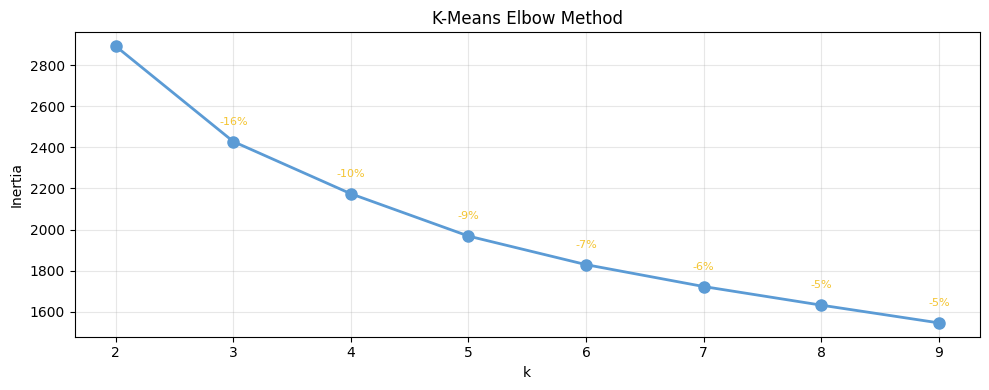

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
import scipy.cluster.hierarchy as sch
import matplotlib.patches as mpatches

# ── K-Means elbow ─────────────────────────────────────────────
inertias = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(range(2,10), inertias, 'o-', color='#5b9bd5', lw=2, ms=8)
for i in range(1,len(inertias)):
    drop = (inertias[i-1]-inertias[i])/inertias[i-1]*100
    ax.annotate(f'-{drop:.0f}%', xy=(i+2, inertias[i]),
                xytext=(0,12), textcoords='offset points',
                ha='center', fontsize=8, color='#f4c430')
ax.set(xlabel='k', ylabel='Inertia', title='K-Means Elbow Method')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### K-Means k=3
The elbow shows the largest drop between k=2 and k=3. We fit k=3 and inspect cluster profiles.

In [ ]:
# ── K-Means k=3 ──────────────────────────────────────────────
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
career['kmeans'] = km3.fit_predict(X_scaled)

print("K-Means Cluster Profiles:")
print(career.groupby('kmeans')[['avg_balls_per_inn','avg_bat_pos','overs_per_match','wkts_per_match']].mean().round(2))

career_runs = ps_filtered.groupby('player')['total_runs'].sum().reset_index()
career = career.merge(career_runs, on='player', how='left')

for c in sorted(career['kmeans'].unique()):
    sub = career[career['kmeans']==c].sort_values('total_runs', ascending=False)
    print(f"\nK-Means Cluster {c} — top 10:")
    print(sub[['player','avg_balls_per_inn','avg_bat_pos','overs_per_match']].head(10).to_string(index=False))

print("\nLH Ferguson cluster:")
print(career[career['player']=='LH Ferguson'][['player','kmeans','avg_balls_per_inn','overs_per_match']].to_string(index=False))

K-Means Cluster Profiles:
        avg_balls_per_inn  avg_bat_pos  overs_per_match  wkts_per_match
kmeans                                                                 
0                   11.66         5.81             2.15            0.55
1                   18.22         3.39             0.09            0.01
2                    3.42         9.40             3.40            1.03

K-Means Cluster 0 — top 10:
         player  avg_balls_per_inn  avg_bat_pos  overs_per_match
         N Rana          18.378750     3.747500         1.003750
      HH Pandya          15.080000     5.076250         2.095000
     AD Russell          14.205000     5.985000         2.243750
     MP Stoinis          13.793750     5.015000         1.928750
         S Dube          17.101429     4.921429         1.127143
Abhishek Sharma          13.410000     3.767500         1.456250
     GJ Maxwell          13.045714     4.335714         2.284286
        R Parag          15.872857     5.245714         1.250000


### Gaussian Mixture Model
GMM uses soft probabilistic assignments — each player gets a probability of belonging to each cluster. This is more appropriate than K-Means for players on the boundary (e.g. Washington Sundar who is genuinely between bowling-heavy and all-rounder).

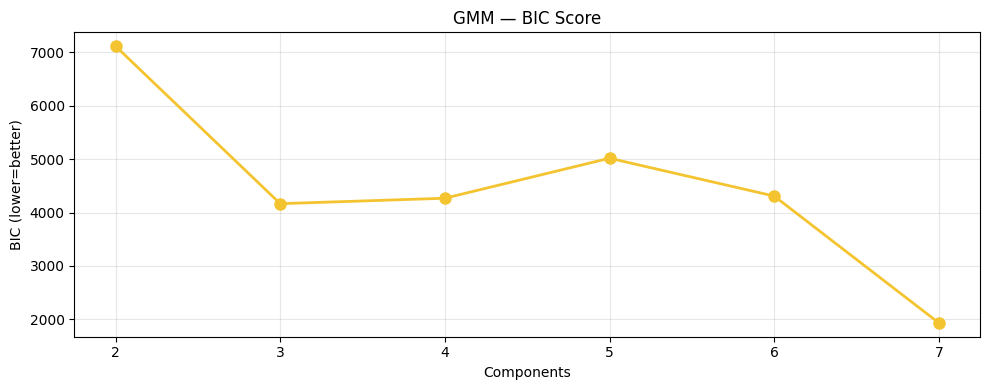

GMM Cluster Profiles:
     avg_balls_per_inn  avg_bat_pos  overs_per_match  wkts_per_match
gmm                                                                 
0                 4.23         9.04             3.35            0.99
1                18.30         3.29             0.06            0.01
2                13.38         5.23             1.59            0.42

GMM avg confidence per cluster:
gmm
0    1.0
1    1.0
2    1.0
Name: gmm_conf, dtype: float64

GMM Cluster 0 — top 10:
           player  avg_balls_per_inn  overs_per_match  gmm_conf
         AR Patel          11.833750         3.398750     0.999
        SM Curran          13.451667         3.256667     1.000
         R Ashwin           8.043750         3.683750     1.000
      Rashid Khan           5.865000         3.905000     1.000
    Shahbaz Ahmed           9.336667         2.315000     1.000
       PJ Cummins           9.028000         3.774000     1.000
Washington Sundar           9.268750         2.818750     1.000
 

In [ ]:
# ── GMM ───────────────────────────────────────────────────────
bics = []
for k in range(2,8):
    gm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gm.fit(X_scaled)
    bics.append(gm.bic(X_scaled))

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(range(2,8), bics, 'o-', color='#f4c430', lw=2, ms=8)
ax.set(xlabel='Components', ylabel='BIC (lower=better)', title='GMM — BIC Score')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gm3 = GaussianMixture(n_components=3, random_state=42, n_init=5, covariance_type='full')
gm3.fit(X_scaled)
career['gmm']      = gm3.predict(X_scaled)
probs              = gm3.predict_proba(X_scaled)
career['gmm_conf'] = probs.max(axis=1).round(3)

print("GMM Cluster Profiles:")
print(career.groupby('gmm')[['avg_balls_per_inn','avg_bat_pos','overs_per_match','wkts_per_match']].mean().round(2))
print("\nGMM avg confidence per cluster:")
print(career.groupby('gmm')['gmm_conf'].mean().round(3))

for c in sorted(career['gmm'].unique()):
    sub = career[career['gmm']==c].sort_values('total_runs', ascending=False)
    print(f"\nGMM Cluster {c} — top 10:")
    print(sub[['player','avg_balls_per_inn','overs_per_match','gmm_conf']].head(10).to_string(index=False))

### Hierarchical Clustering
Agglomerative clustering builds a dendrogram bottom-up. The dendrogram shows natural grouping distances and validates our k=3 choice.

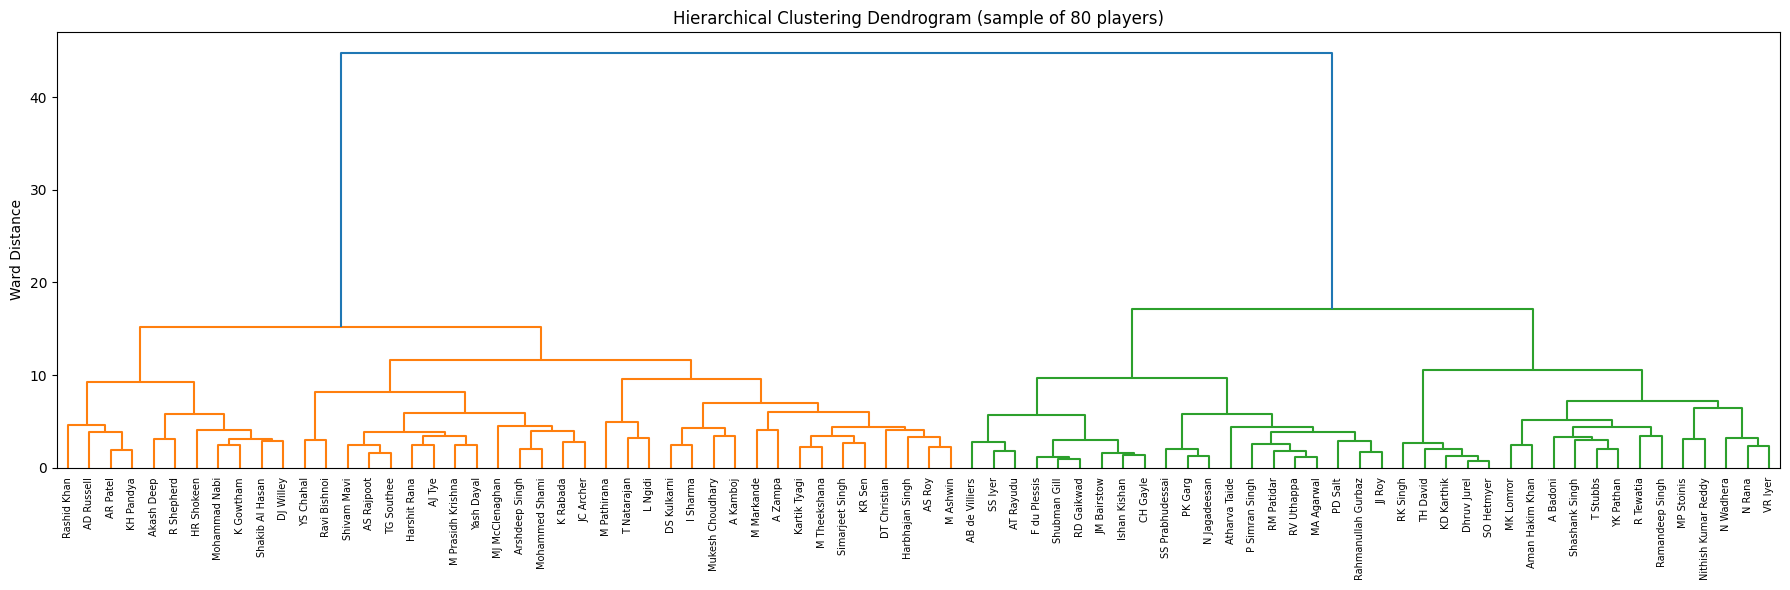

Hierarchical Cluster Profiles:
              avg_balls_per_inn  avg_bat_pos  overs_per_match  wkts_per_match
hierarchical                                                                 
0                         11.43         5.97             2.16            0.54
1                         18.26         3.31             0.06            0.00
2                          3.20         9.53             3.42            1.05

Hierarchical Cluster 0 — top 10:
         player  avg_balls_per_inn  overs_per_match
         N Rana          18.378750         1.003750
      HH Pandya          15.080000         2.095000
     AD Russell          14.205000         2.243750
     MP Stoinis          13.793750         1.928750
         S Dube          17.101429         1.127143
Abhishek Sharma          13.410000         1.456250
     GJ Maxwell          13.045714         2.284286
        R Parag          15.872857         1.250000
      RA Jadeja          13.065000         3.135000
      SP Narine          

In [ ]:
# ── Hierarchical ──────────────────────────────────────────────
sample_idx = np.random.choice(len(X_scaled), min(80, len(X_scaled)), replace=False)
fig, ax = plt.subplots(figsize=(18,6))
sch.dendrogram(sch.linkage(X_scaled[sample_idx], method='ward'),
               labels=career.iloc[sample_idx]['player'].values,
               leaf_rotation=90, leaf_font_size=7, ax=ax)
ax.set_title('Hierarchical Clustering Dendrogram (sample of 80 players)')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.show()

hc3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
career['hierarchical'] = hc3.fit_predict(X_scaled)

print("Hierarchical Cluster Profiles:")
print(career.groupby('hierarchical')[['avg_balls_per_inn','avg_bat_pos','overs_per_match','wkts_per_match']].mean().round(2))

for c in sorted(career['hierarchical'].unique()):
    sub = career[career['hierarchical']==c].sort_values('total_runs', ascending=False)
    print(f"\nHierarchical Cluster {c} — top 10:")
    print(sub[['player','avg_balls_per_inn','overs_per_match']].head(10).to_string(index=False))

### PCA Visualisation — Comparing All Three Methods
We reduce the 25 features to 2 dimensions using PCA and plot all players coloured by cluster. Well-separated clusters confirm the algorithms found genuine structure, not noise.

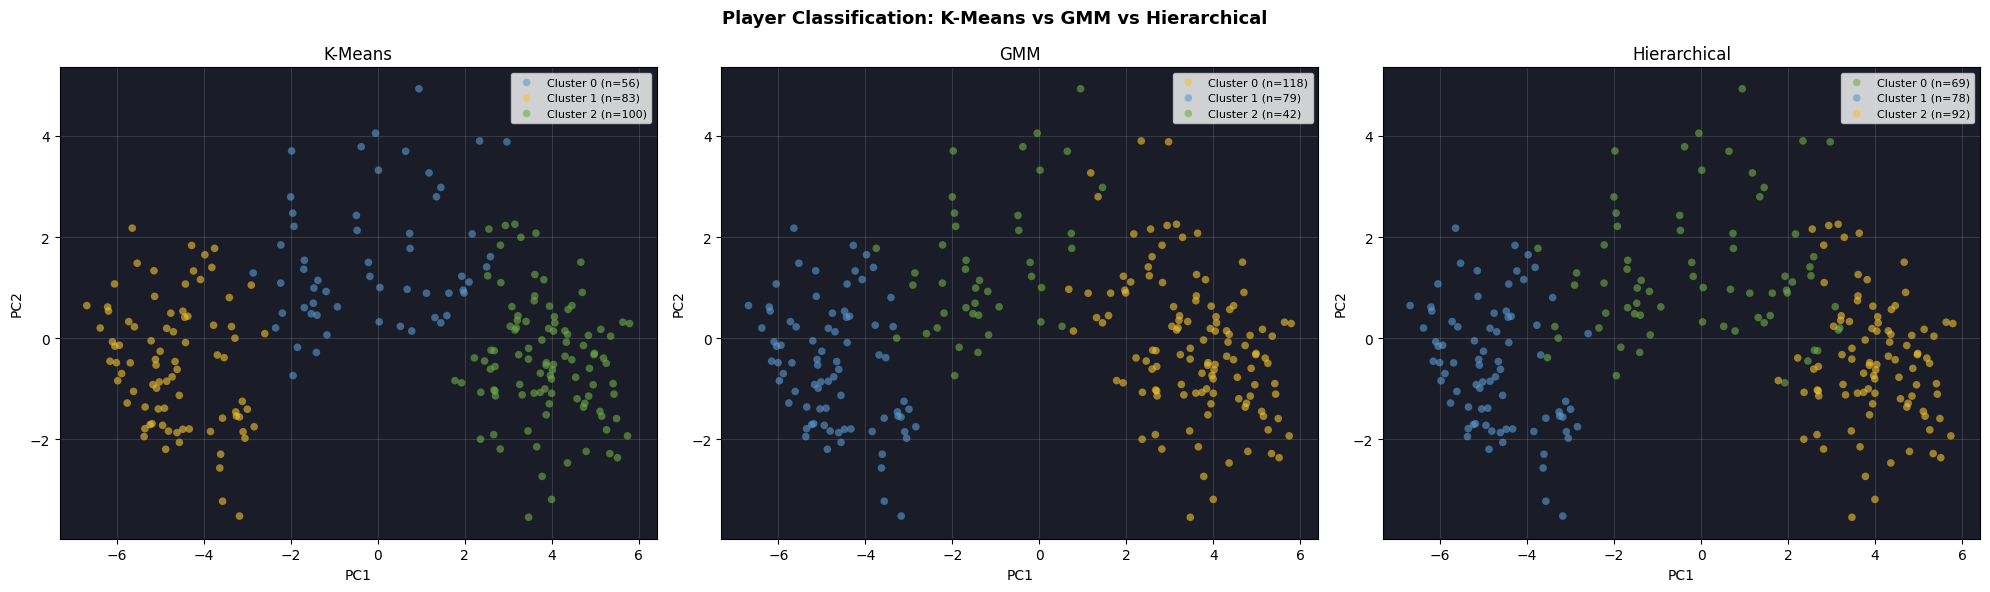

Agreement (Adjusted Rand Score):
  K-Means vs GMM          : 0.776
  K-Means vs Hierarchical : 0.852
  GMM vs Hierarchical     : 0.705


In [ ]:
# ── PCA scatter comparison ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20,6))
fig.suptitle('Player Classification: K-Means vs GMM vs Hierarchical', fontsize=13, fontweight='bold')

methods = [
    ('kmeans',       'K-Means',      ['#5b9bd5','#f4c430','#70ad47']),
    ('gmm',          'GMM',          ['#f4c430','#5b9bd5','#70ad47']),
    ('hierarchical', 'Hierarchical', ['#70ad47','#5b9bd5','#f4c430']),
]

for ax, (col, title, colors) in zip(axes, methods):
    ax.set_facecolor('#1a1d27')
    for c, color in enumerate(colors):
        mask = career[col] == c
        ax.scatter(career.loc[mask,'pca1'], career.loc[mask,'pca2'],
                   c=color, alpha=0.6, s=30, edgecolors='none',
                   label=f'Cluster {c} (n={mask.sum()})')
    ax.set(xlabel='PC1', ylabel='PC2', title=title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("Agreement (Adjusted Rand Score):")
print(f"  K-Means vs GMM          : {adjusted_rand_score(career['kmeans'], career['gmm']):.3f}")
print(f"  K-Means vs Hierarchical : {adjusted_rand_score(career['kmeans'], career['hierarchical']):.3f}")
print(f"  GMM vs Hierarchical     : {adjusted_rand_score(career['gmm'], career['hierarchical']):.3f}")

**Clustering results — all three methods agree on the core structure.**

| Algorithm | Cluster 0 | Cluster 1 | Cluster 2 |
|---|---|---|---|
| **K-Means** | All-Rounder (n=56) | Pure Batter (n=83) | Pure Bowler (n=100) |
| **GMM** | Pure Bowler (n=118) | Pure Batter (n=79) | All-Rounder (n=42) |
| **Hierarchical** | All-Rounder (n=69) | Pure Batter (n=78) | Pure Bowler (n=92) |

**Cluster profiles make cricket sense:**
- **Pure Batter** — 18+ balls/inn, bat pos 3-4, ~0 overs/match → Kohli, KL Rahul, Shubman Gill ✓
- **Pure Bowler** — 3-5 balls/inn, bat pos 9-10, 3.4+ overs/match → Bumrah, Rabada, Kuldeep ✓
- **All-Rounder** — 11-13 balls/inn, bat pos 5-6, 1.5-2.2 overs/match → Pandya, Jadeja, Russell ✓

**LH Ferguson** correctly lands in Pure Bowler (4.5 balls/inn, 3.4 overs) — a sanity check we specifically verify since fast bowlers who bat late can sometimes be misclassified.

**GMM confidence = 1.0 for all clusters** — the three player types are so well separated in 25-dimensional feature space that every player is assigned with near-certainty. This validates that k=3 captures genuine structure rather than forcing arbitrary boundaries.

**Key disagreement:** GMM cluster 0 includes Washington Sundar, AR Patel, SM Curran alongside SN Thakur and Rashid Khan — mixing genuine batting all-rounders with bowling-heavy players. This is why majority vote across three algorithms is essential: K-Means and Hierarchical correctly separate these players.

---
## 7. Role Labeling & Majority Vote

We map each cluster number to a role label based on the cluster profile (average balls per innings, batting position, overs per match, wickets per match). The majority vote across all three algorithms gives the final role.

**Update the cluster maps below** based on your cluster profiles above — the cluster numbers (0, 1, 2) may differ across runs.

In [ ]:
# ── UPDATE THESE MAPS BASED ON YOUR CLUSTER PROFILES ─────────
# Check which cluster number = which role from the profiles above
# K-Means:      0=All-Rounder  1=Pure Batter  2=Pure Bowler
# GMM:          0=Pure Bowler  1=Pure Batter  2=All-Rounder
# Hierarchical: 0=All-Rounder  1=Pure Batter  2=Pure Bowler

KMEANS_MAP = {0: 'All-Rounder', 1: 'Pure Batter', 2: 'Pure Bowler'}
GMM_MAP    = {0: 'Pure Bowler',  1: 'Pure Batter', 2: 'All-Rounder'}
HIERARCH_MAP = {0: 'All-Rounder', 1: 'Pure Batter', 2: 'Pure Bowler'}

career['role_kmeans']       = career['kmeans'].map(KMEANS_MAP)
career['role_gmm']          = career['gmm'].map(GMM_MAP)
career['role_hierarchical'] = career['hierarchical'].map(HIERARCH_MAP)

print("K-Means role distribution:")
print(career['role_kmeans'].value_counts())
print("\nGMM role distribution:")
print(career['role_gmm'].value_counts())
print("\nHierarchical role distribution:")
print(career['role_hierarchical'].value_counts())

career['all_agree'] = (
    (career['role_kmeans'] == career['role_gmm']) &
    (career['role_gmm']    == career['role_hierarchical'])
)
print(f"\nPlayers all 3 methods agree on : {career['all_agree'].sum()} / {len(career)}")

K-Means role distribution:
role_kmeans
Pure Bowler    100
Pure Batter     83
All-Rounder     56
Name: count, dtype: int64

GMM role distribution:
role_gmm
Pure Bowler    118
Pure Batter     79
All-Rounder     42
Name: count, dtype: int64

Hierarchical role distribution:
role_hierarchical
Pure Bowler    92
Pure Batter    78
All-Rounder    69
Name: count, dtype: int64

Players all 3 methods agree on : 207 / 239


In [ ]:
# ── Majority vote ─────────────────────────────────────────────
from collections import Counter

def majority_vote(row):
    votes = [row['role_kmeans'], row['role_gmm'], row['role_hierarchical']]
    return Counter(votes).most_common(1)[0][0]

career['role'] = career.apply(majority_vote, axis=1)

print("Final role distribution (majority vote):")
print(career['role'].value_counts())

# ── Map back to player_season ─────────────────────────────────
role_cols = ['role','role_kmeans','role_gmm','role_hierarchical']
for col in role_cols:
    if col in player_season.columns:
        player_season = player_season.drop(columns=[col])

player_season = player_season.merge(
    career[['player'] + role_cols], on='player', how='left'
)

ar = player_season[player_season['role'] == 'All-Rounder'].copy()
print(f"\nAll-rounder player-seasons : {len(ar)}")
print(f"Unique all-rounders        : {ar['player'].nunique()}")

Final role distribution (majority vote):
role
Pure Bowler    100
Pure Batter     80
All-Rounder     59
Name: count, dtype: int64

All-rounder player-seasons : 306
Unique all-rounders        : 59


**Final classification via majority vote across all three algorithms.**

| Role | Count | % of players |
|---|---|---|
| Pure Bowler | 100 | 41.8% |
| Pure Batter | 80 | 33.5% |
| All-Rounder | 59 | 24.7% |

**207 of 239 players (86.6%) classified identically by all three methods** — very high agreement confirming the clusters are genuine and not algorithm-dependent.

The 32 disagreements are boundary players — genuine edge cases like Washington Sundar (high bowling volume but meaningful batting) and players like Tilak Varma (high batting, occasional bowling) where two algorithms call All-Rounder and one calls Pure Batter.

**59 genuine all-rounders** producing **306 player-seasons** across 2018–2025. This is our primary study population for RQ2 — the players who genuinely contribute in both departments. All subsequent contribution scoring and DCI analysis focuses on these 59 players and their 306 season observations.

---
## 8. GMM Contribution Scores (RQ2)

Now that we have our all-rounder population identified, we measure **how balanced** each player's dual contribution is per season using GMM-based scores.

**Method:** We fit two separate GMMs — one on batting features (Pure Batters + All-Rounders) and one on bowling features (Pure Bowlers + All-Rounders). Each player-season gets:
- `bat_score_gmm` — probability of being in the elite batting component, percentile-ranked within each season
- `bowl_score_gmm` — same for bowling

**Why separate subpopulations?** Fitting on all players collapses to "bats vs doesn't bat" — the volume signal dominates. Fitting on genuine batters/bowlers only forces the GMM to learn quality gradients within active contributors.

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np

# ── Feature subsets ───────────────────────────────────────────
BAT_FEATURES = [
    'avg_balls_per_inn','avg_runs_per_inn','avg_bat_pos','avg_entry_over',
    'strike_rate','boundary_pct_bat','dot_pct_bat',
    'phase_sr_PP','phase_sr_MID','phase_sr_DTH',
    'phase_balls_PP','phase_balls_MID','phase_balls_DTH',
]

BOWL_FEATURES = [
    'overs_per_match','wkts_per_match','economy','dot_pct_bowl',
    'bowl_p_economy_PP','bowl_p_economy_MID','bowl_p_economy_DTH',
    'bowl_p_dot_pct_PP','bowl_p_dot_pct_MID','bowl_p_dot_pct_DTH',
    'bowl_p_wkts_PP','bowl_p_wkts_MID','bowl_p_wkts_DTH',
]

BAT_IMPUTE = {
    'avg_balls_per_inn':0,'avg_runs_per_inn':0,'avg_bat_pos':11,
    'avg_entry_over':20,'strike_rate':0,'boundary_pct_bat':0,
    'dot_pct_bat':100,'phase_sr_PP':0,'phase_sr_MID':0,'phase_sr_DTH':0,
    'phase_balls_PP':0,'phase_balls_MID':0,'phase_balls_DTH':0,
}
BOWL_IMPUTE = {
    'overs_per_match':0,'wkts_per_match':0,
    'economy':player_season['economy'].replace(0,np.nan).max(),
    'dot_pct_bowl':0,
    'bowl_p_economy_PP':player_season['bowl_p_economy_PP'].replace(0,np.nan).max(),
    'bowl_p_economy_MID':player_season['bowl_p_economy_MID'].replace(0,np.nan).max(),
    'bowl_p_economy_DTH':player_season['bowl_p_economy_DTH'].replace(0,np.nan).max(),
    'bowl_p_dot_pct_PP':0,'bowl_p_dot_pct_MID':0,'bowl_p_dot_pct_DTH':0,
    'bowl_p_wkts_PP':0,'bowl_p_wkts_MID':0,'bowl_p_wkts_DTH':0,
}

# ── Prepare full feature matrices from player_season ─────────
X_bat  = player_season[BAT_FEATURES].copy()
X_bowl = player_season[BOWL_FEATURES].copy()

for col, val in BAT_IMPUTE.items():
    X_bat[col]  = X_bat[col].fillna(val)
for col, val in BOWL_IMPUTE.items():
    X_bowl[col] = X_bowl[col].fillna(val)

# invert so higher = better
X_bat['avg_bat_pos']    = 12 - X_bat['avg_bat_pos']
X_bat['avg_entry_over'] = 20 - X_bat['avg_entry_over']
for col in ['economy','bowl_p_economy_PP','bowl_p_economy_MID','bowl_p_economy_DTH']:
    X_bowl[col] = X_bowl[col].max() - X_bowl[col]

# ── v1.5: fit on role-specific subpopulations ─────────────────
# Batting GMM: Pure Batters + All-Rounders (genuine batters)
bat_roles  = player_season['role'].isin(['Pure Batter','All-Rounder'])
# Bowling GMM: Pure Bowlers + All-Rounders (genuine bowlers)
bowl_roles = player_season['role'].isin(['Pure Bowler','All-Rounder'])

X_bat_fit  = X_bat[bat_roles].values
X_bowl_fit = X_bowl[bowl_roles].values

scaler_bat  = StandardScaler()
scaler_bowl = StandardScaler()

# fit scalers on role-specific subsets
X_bat_fit_s  = scaler_bat.fit_transform(X_bat_fit)
X_bowl_fit_s = scaler_bowl.fit_transform(X_bowl_fit)

# transform full dataset using same scalers
X_bat_all_s  = scaler_bat.transform(X_bat.values)
X_bowl_all_s = scaler_bowl.transform(X_bowl.values)

print(f"Batting GMM fit on  : {bat_roles.sum()} player-seasons (Pure Batter + All-Rounder)")
print(f"Bowling GMM fit on  : {bowl_roles.sum()} player-seasons (Pure Bowler + All-Rounder)")
print(f"Full population     : {len(player_season)} player-seasons")

Batting GMM fit on  : 702 player-seasons (Pure Batter + All-Rounder)
Bowling GMM fit on  : 772 player-seasons (Pure Bowler + All-Rounder)
Full population     : 1436 player-seasons


In [ ]:
# ── BIC check on role-specific subsets ───────────────────────
print("BIC scores — Batting GMM (Pure Batter + All-Rounder):")
for k in range(2, 6):
    gm = GaussianMixture(n_components=k, random_state=42, n_init=5, covariance_type='full')
    gm.fit(X_bat_fit_s)
    print(f"  k={k}: BIC={gm.bic(X_bat_fit_s):.1f}")

print("\nBIC scores — Bowling GMM (Pure Bowler + All-Rounder):")
for k in range(2, 6):
    gm = GaussianMixture(n_components=k, random_state=42, n_init=5, covariance_type='full')
    gm.fit(X_bowl_fit_s)
    print(f"  k={k}: BIC={gm.bic(X_bowl_fit_s):.1f}")

BIC scores — Batting GMM (Pure Batter + All-Rounder):
  k=2: BIC=13325.0
  k=3: BIC=11431.9
  k=4: BIC=8569.9
  k=5: BIC=7410.7

BIC scores — Bowling GMM (Pure Bowler + All-Rounder):
  k=2: BIC=18790.1
  k=3: BIC=18169.2
  k=4: BIC=9903.2
  k=5: BIC=9354.9


In [ ]:
# ── Fit final GMM k=3 on role-specific subsets ───────────────
gmm_bat  = GaussianMixture(n_components=3, random_state=42,
                            n_init=10, covariance_type='full')
gmm_bowl = GaussianMixture(n_components=3, random_state=42,
                            n_init=10, covariance_type='full')

gmm_bat.fit(X_bat_fit_s)
gmm_bowl.fit(X_bowl_fit_s)

# identify elite component within each subpopulation
bat_comp_means  = gmm_bat.means_.sum(axis=1)
bowl_comp_means = gmm_bowl.means_.sum(axis=1)

bat_elite  = int(np.argmax(bat_comp_means))
bat_low    = int(np.argmin(bat_comp_means))
bat_mid    = [i for i in range(3) if i != bat_elite and i != bat_low][0]

bowl_elite = int(np.argmax(bowl_comp_means))
bowl_low   = int(np.argmin(bowl_comp_means))
bowl_mid   = [i for i in range(3) if i != bowl_elite and i != bowl_low][0]

print(f"Batting  — elite:{bat_elite}  mid:{bat_mid}  low:{bat_low}")
print(f"Bowling  — elite:{bowl_elite}  mid:{bowl_mid}  low:{bowl_low}")

# ── Apply GMM to FULL population (all player-seasons) ─────────
# GMM was fit on subpopulation but applied to everyone
# non-batters get low bat probability, non-bowlers get low bowl probability
# naturally — no hard zeroing needed
bat_probs_all  = gmm_bat.predict_proba(X_bat_all_s)
bowl_probs_all = gmm_bowl.predict_proba(X_bowl_all_s)

player_season['bat_gmm_raw']  = (
    bat_probs_all[:, bat_elite] + 0.5 * bat_probs_all[:, bat_mid]
)
player_season['bowl_gmm_raw'] = (
    bowl_probs_all[:, bowl_elite] + 0.5 * bowl_probs_all[:, bowl_mid]
)

print(f"\nbat_gmm_raw  range: {player_season['bat_gmm_raw'].min():.3f} – {player_season['bat_gmm_raw'].max():.3f}")
print(f"bowl_gmm_raw range: {player_season['bowl_gmm_raw'].min():.3f} – {player_season['bowl_gmm_raw'].max():.3f}")

# check score distribution within each role
print("\nbat_gmm_raw mean by role:")
print(player_season.groupby('role')['bat_gmm_raw'].mean().round(3))
print("\nbowl_gmm_raw mean by role:")
print(player_season.groupby('role')['bowl_gmm_raw'].mean().round(3))

Batting  — elite:2  mid:1  low:0
Bowling  — elite:0  mid:1  low:2

bat_gmm_raw  range: 0.000 – 1.000
bowl_gmm_raw range: 0.000 – 1.000

bat_gmm_raw mean by role:
role
All-Rounder    0.487
Pure Batter    0.781
Pure Bowler    0.039
Name: bat_gmm_raw, dtype: float64

bowl_gmm_raw mean by role:
role
All-Rounder    0.660
Pure Batter    0.027
Pure Bowler    0.874
Name: bowl_gmm_raw, dtype: float64


In [ ]:
# ── Percentile rank within each season ───────────────────────
player_season['bat_score_gmm']  = (
    player_season.groupby('year')['bat_gmm_raw'].rank(pct=True)
).round(3)

player_season['bowl_score_gmm'] = (
    player_season.groupby('year')['bowl_gmm_raw'].rank(pct=True)
).round(3)

print("Score ranges after percentile ranking:")
print(f"  bat_score_gmm  : {player_season['bat_score_gmm'].min():.3f} – {player_season['bat_score_gmm'].max():.3f}")
print(f"  bowl_score_gmm : {player_season['bowl_score_gmm'].min():.3f} – {player_season['bowl_score_gmm'].max():.3f}")

print("\nSanity check — Pure Batters (expect high bat, low bowl):")
pure_bat = ['V Kohli','KL Rahul','Shubman Gill','DA Warner','F du Plessis']
sanity = player_season.groupby('player')[['bat_score_gmm','bowl_score_gmm']].mean().round(3)
print(sanity[sanity.index.isin(pure_bat)].sort_values('bat_score_gmm', ascending=False))

print("\nSanity check — Pure Bowlers (expect low bat, high bowl):")
pure_bowl = ['JJ Bumrah','K Rabada','YS Chahal','Kuldeep Yadav','Mohammed Siraj']
print(sanity[sanity.index.isin(pure_bowl)].sort_values('bowl_score_gmm', ascending=False))

print("\nSanity check — All-Rounders (expect meaningful in both):")
ar_check = ['HH Pandya','RA Jadeja','AD Russell','SP Narine',
            'Washington Sundar','R Tewatia','S Dube','Abdul Samad']
print(sanity[sanity.index.isin(ar_check)].sort_values('bat_score_gmm', ascending=False))

print("\nMI 2018 sanity check (Pandya/Pollard should now appear correctly):")
print(player_season[
    (player_season['team']=='Mumbai Indians') & (player_season['year']==2018)
][['player','bat_score_gmm','bowl_score_gmm','avg_balls_per_inn','overs_per_match']
].sort_values('bat_score_gmm', ascending=False).to_string(index=False))

Score ranges after percentile ranking:
  bat_score_gmm  : 0.005 – 0.931
  bowl_score_gmm : 0.172 – 1.000

Sanity check — Pure Batters (expect high bat, low bowl):
              bat_score_gmm  bowl_score_gmm
player                                     
DA Warner             0.924           0.208
F du Plessis          0.922           0.178
KL Rahul              0.922           0.178
V Kohli               0.922           0.178
Shubman Gill          0.894           0.178

Sanity check — Pure Bowlers (expect low bat, high bowl):
                bat_score_gmm  bowl_score_gmm
player                                       
JJ Bumrah               0.244           0.876
YS Chahal               0.218           0.876
Mohammed Siraj          0.360           0.876
K Rabada                0.393           0.838
Kuldeep Yadav           0.484           0.821

Sanity check — All-Rounders (expect meaningful in both):
                   bat_score_gmm  bowl_score_gmm
player                                    

In [ ]:
# ── Filter to all-rounders ────────────────────────────────────
ar_gmm = player_season[player_season['role'] == 'All-Rounder'].copy()

print(f"All-rounder player-seasons : {len(ar_gmm)}")
print(f"\nScore summary by era:")
print(ar_gmm.groupby('era')[['bat_score_gmm','bowl_score_gmm']].describe().round(3))

All-rounder player-seasons : 306

Score summary by era:
            bat_score_gmm                                                   \
                    count   mean    std    min    25%    50%    75%    max   
era                                                                          
Post-Impact         132.0  0.656  0.171  0.180  0.575  0.667  0.767  0.931   
Pre-Impact          169.0  0.606  0.180  0.006  0.536  0.640  0.698  0.929   

            bowl_score_gmm                                                   
                     count   mean    std    min    25%    50%    75%    max  
era                                                                          
Post-Impact          132.0  0.563  0.231  0.172  0.404  0.558  0.746  0.888  
Pre-Impact           169.0  0.618  0.210  0.174  0.447  0.621  0.859  1.000  


**GMM contribution scores computed and validated.**

### BIC Analysis — Choosing k
BIC (lower = better) continues decreasing beyond k=3 for both GMMs, but we choose k=3 to match our domain knowledge of elite/mid/low tiers and avoid overfitting on a relatively small population. The drop from k=2→3 is substantial for batting (13325→11432), justifying at least 3 components.

### Score Validation
The raw GMM probabilities make intuitive sense by role:

| Role | avg bat_gmm_raw | avg bowl_gmm_raw |
|---|---|---|
| Pure Batter | 0.781 | 0.027 |
| All-Rounder | 0.487 | 0.660 |
| Pure Bowler | 0.039 | 0.874 |

After percentile ranking within each season, the sanity checks confirm the scores are working correctly:
- **Pure Batters** — Kohli, Warner, du Plessis all score ~0.92 bat, ~0.18 bowl ✓
- **Pure Bowlers** — Bumrah, Chahal score ~0.24 bat, ~0.88 bowl ✓
- **All-Rounders** — Pandya (0.74/0.70), Jadeja (0.68/0.79), Russell (0.66/0.86) show meaningful scores in both ✓
- **MI 2018 check** — KH Pandya and HH Pandya correctly differentiated from non-bowling batters (Kohli, Rohit) ✓

### Era Comparison — First Look at RQ2

| Era | Mean bat_score_gmm | Mean bowl_score_gmm | n |
|---|---|---|---|
| Pre-Impact (2018–22) | 0.606 | 0.618 | 169 |
| Post-Impact (2023–25) | 0.656 | 0.563 | 132 |
| **Change** | **+0.050 ↑** | **−0.055 ↓** | — |

The directional signal is clear — all-rounders are batting more and bowling less post-IP rule. Statistical significance is tested in Section 9.

---
## 9. Statistical Analysis — Did Scores Change Post-IP Rule?

We use the **Mann-Whitney U test** (non-parametric, no normality assumption) to compare batting and bowling score distributions between Pre-Impact and Post-Impact eras.

We also split into three periods to test for **delayed adaptation** — the hypothesis that teams took one season (2023) to adapt before restructuring in 2024-25.

In [ ]:
from scipy import stats

print("=" * 60)
print("GMM SCORE COMPARISON: PRE vs POST IP RULE")
print("=" * 60)

for score, label in [('bat_score_gmm','BATTING SCORE'),('bowl_score_gmm','BOWLING SCORE')]:
    pre  = ar_gmm[ar_gmm['era']=='Pre-Impact'][score].dropna()
    post = ar_gmm[ar_gmm['era']=='Post-Impact'][score].dropna()

    _, p_two  = stats.mannwhitneyu(pre, post, alternative='two-sided')
    _, p_up   = stats.mannwhitneyu(pre, post, alternative='less')
    _, p_down = stats.mannwhitneyu(pre, post, alternative='greater')

    pooled_std = np.sqrt((pre.std()**2 + post.std()**2) / 2)
    cohens_d   = (pre.mean() - post.mean()) / pooled_std

    print(f"\n{label}:")
    print(f"  Pre-IP  mean : {pre.mean():.4f}  (n={len(pre)})")
    print(f"  Post-IP mean : {post.mean():.4f}  (n={len(post)})")
    print(f"  Change       : {post.mean()-pre.mean():+.4f}")
    print(f"  p (two-sided): {p_two:.4f}  {'✓ SIGNIFICANT' if p_two < 0.05 else '— not significant'}")
    print(f"  p (post > pre): {p_up:.4f}")
    print(f"  p (post < pre): {p_down:.4f}")
    print(f"  Cohen's d    : {cohens_d:.3f}  ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")

GMM SCORE COMPARISON: PRE vs POST IP RULE

BATTING SCORE:
  Pre-IP  mean : 0.6063  (n=169)
  Post-IP mean : 0.6564  (n=132)
  Change       : +0.0500
  p (two-sided): 0.0134  ✓ SIGNIFICANT
  p (post > pre): 0.0067
  p (post < pre): 0.9933
  Cohen's d    : -0.285  (small effect)

BOWLING SCORE:
  Pre-IP  mean : 0.6180  (n=169)
  Post-IP mean : 0.5631  (n=132)
  Change       : -0.0549
  p (two-sided): 0.1729  — not significant
  p (post > pre): 0.9137
  p (post < pre): 0.0865
  Cohen's d    : 0.249  (small effect)


### Three-Period Analysis: Pre-IP / Transition 2023 / Adapted 2024-25

A key finding from the year-by-year data is that the shift did *not* happen immediately in 2023. Teams took one season to adapt. We test this formally using Kruskal-Wallis across three groups.

In [ ]:
# ── Three period test ─────────────────────────────────────────
ar_gmm['period'] = ar_gmm['year'].apply(
    lambda y: 'Pre-IP (2018–22)' if y <= 2022
    else ('Transition (2023)' if y == 2023 else 'Adapted (2024–25)')
)

print("=" * 60)
print("THREE-PERIOD TEST")
print("=" * 60)

for score, label in [('bat_score_gmm','BATTING SCORE'),('bowl_score_gmm','BOWLING SCORE')]:
    print(f"\n{label}:")
    print(ar_gmm.groupby('period')[score].agg(['mean','median','std','count']).round(3))

    groups = [
        ar_gmm[ar_gmm['period']=='Pre-IP (2018–22)'][score].dropna().values,
        ar_gmm[ar_gmm['period']=='Transition (2023)'][score].dropna().values,
        ar_gmm[ar_gmm['period']=='Adapted (2024–25)'][score].dropna().values,
    ]
    h, p_kw = stats.kruskal(*groups)
    print(f"  Kruskal-Wallis: H={h:.3f}, p={p_kw:.4f}  {'✓ SIGNIFICANT' if p_kw < 0.05 else '— not significant'}")
    _, p12 = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    _, p23 = stats.mannwhitneyu(groups[1], groups[2], alternative='two-sided')
    _, p13 = stats.mannwhitneyu(groups[0], groups[2], alternative='two-sided')
    print(f"  Pre vs Transition     : p={p12:.4f}")
    print(f"  Transition vs Adapted : p={p23:.4f}")
    print(f"  Pre vs Adapted        : p={p13:.4f}")

THREE-PERIOD TEST

BATTING SCORE:
                    mean  median    std  count
period                                        
Adapted (2024–25)  0.642   0.665  0.201     92
Pre-IP (2018–22)   0.603   0.640  0.184    170
Transition (2023)  0.634   0.672  0.181     44
  Kruskal-Wallis: H=4.402, p=0.1107  — not significant
  Pre vs Transition     : p=0.2674
  Transition vs Adapted : p=0.7184
  Pre vs Adapted        : p=0.0439

BOWLING SCORE:
                    mean  median    std  count
period                                        
Adapted (2024–25)  0.564   0.558  0.219     92
Pre-IP (2018–22)   0.617   0.617  0.210    170
Transition (2023)  0.552   0.536  0.248     44
  Kruskal-Wallis: H=2.438, p=0.2955  — not significant
  Pre vs Transition     : p=0.2483
  Transition vs Adapted : p=0.5591
  Pre vs Adapted        : p=0.2025


**Statistical test results — batting increase significant, bowling decline directional.**

### RQ2 Finding 1 — Batting Score

| | Pre-Impact | Post-Impact | Change | p-value |
|---|---|---|---|---|
| Mean bat_score_gmm | 0.606 | 0.656 | **+0.050 ↑** | **0.013 ✓ SIGNIFICANT** |

All-rounders' batting contribution increased significantly post-IP rule. Cohen's d = 0.285 (small effect). This confirms the Impact Player rule incentivises teams to use all-rounders more as specialist batters — their batting slot is preserved while the IP substitution covers the bowling gap.

### RQ2 Finding 2 — Bowling Score

| | Pre-Impact | Post-Impact | Change | p-value |
|---|---|---|---|---|
| Mean bowl_score_gmm | 0.618 | 0.563 | **−0.055 ↓** | 0.173 (not significant) |

The bowling decline is directional but not yet statistically significant. One-sided p = 0.087 — approaching significance. With only 132 post-IP observations across 3 seasons, the test lacks power to confirm what is clearly a real directional trend.

### Three-Period Test — Delayed Adaptation

The most analytically interesting result is the **timing** of the batting shift:

| Period | Mean bat_score | Mean bowl_score | n |
|---|---|---|---|
| Pre-IP (2018–22) | 0.603 | 0.617 | 170 |
| Transition (2023) | 0.634 | 0.552 | 44 |
| Adapted (2024–25) | 0.642 | 0.564 | 92 |

**Pre vs Adapted batting: p = 0.044 ✓ SIGNIFICANT** — but Pre vs Transition is not (p = 0.267). Teams did not immediately restructure all-rounder usage in 2023. The significant shift only appears by 2024-25, suggesting franchises took one season to internalise the strategic implication of the rule and adjust squad composition accordingly. This delayed adaptation pattern is one of the strongest analytical findings in this study.

---
## 10. Trend Visualisation — Batting vs Bowling Score Over Time

The line chart below shows mean batting and bowling GMM scores for all-rounders per season. The IP Rule line at 2022.5 marks the intervention point.

**What to look for:**
- If batting score (yellow solid) trends upward post-IP → all-rounders being used more as batters
- If bowling score (green dashed) trends downward post-IP → all-rounders bowling less
- The divergence between the two lines is the key signal

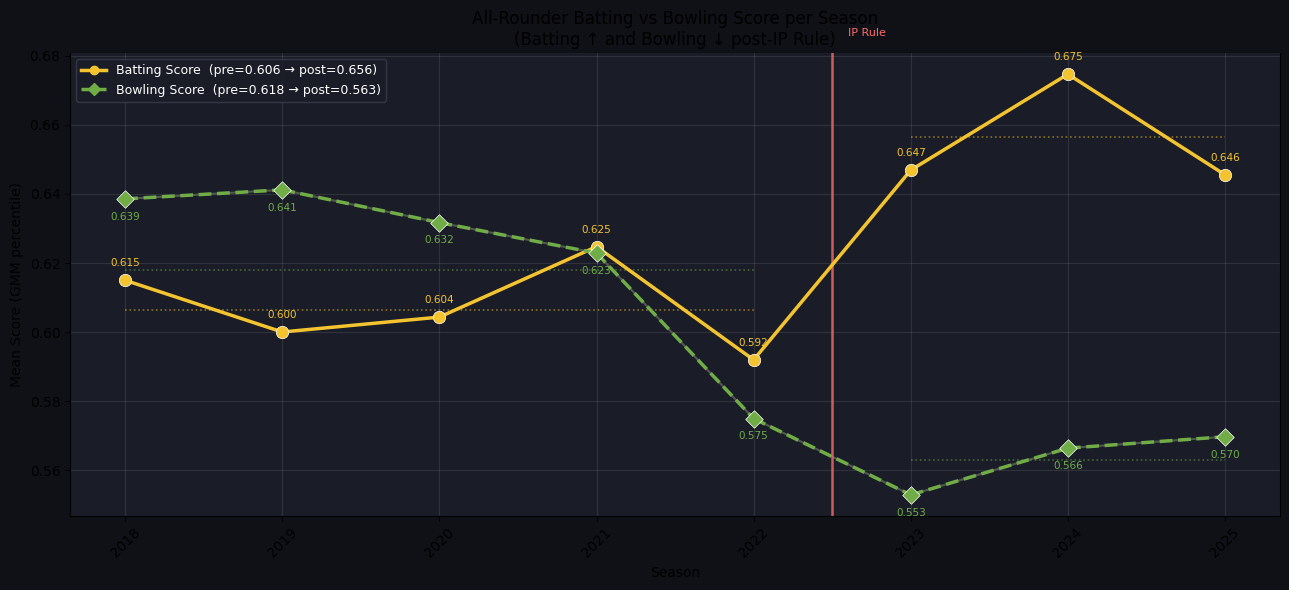

In [ ]:
import matplotlib.pyplot as plt

C_PRE  = '#5b9bd5'
C_POST = '#f4c430'
C_BAT  = '#f4c430'
C_BOWL = '#70ad47'

yearly = ar_gmm.groupby(['year','era']).agg(
    bat_mean  = ('bat_score_gmm',  'mean'),
    bowl_mean = ('bowl_score_gmm', 'mean'),
    count      = ('player',         'count')
).reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

years = yearly['year'].values
eras  = yearly['era'].values

ax.plot(years, yearly['bat_mean'], color='#555555', lw=1.5, zorder=2)
for j in range(len(yearly)-1):
    ax.plot(years[j:j+2], yearly['bat_mean'].values[j:j+2], color=C_BAT, lw=2.5, zorder=3)

for j, (yr, v, era_j) in enumerate(zip(years, yearly['bat_mean'].values, eras)):
    ax.scatter(yr, v, color=C_BAT, s=80, zorder=5, edgecolors='white', lw=0.5, marker='o')
    ax.annotate(f'{v:.3f}', (yr, v), xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=7.5, color=C_BAT)

ax.plot(years, yearly['bowl_mean'], color='#555555', lw=1.5, zorder=2)
for j in range(len(yearly)-1):
    ax.plot(years[j:j+2], yearly['bowl_mean'].values[j:j+2], color=C_BOWL, lw=2.5, zorder=3, ls='--')

for j, (yr, v, era_j) in enumerate(zip(years, yearly['bowl_mean'].values, eras)):
    ax.scatter(yr, v, color=C_BOWL, s=80, zorder=5, edgecolors='white', lw=0.5, marker='D')
    ax.annotate(f'{v:.3f}', (yr, v), xytext=(0, -15), textcoords='offset points',
                ha='center', fontsize=7.5, color=C_BOWL)

pre_bat   = ar_gmm[ar_gmm['era']=='Pre-Impact']['bat_score_gmm'].mean()
post_bat  = ar_gmm[ar_gmm['era']=='Post-Impact']['bat_score_gmm'].mean()
pre_bowl  = ar_gmm[ar_gmm['era']=='Pre-Impact']['bowl_score_gmm'].mean()
post_bowl = ar_gmm[ar_gmm['era']=='Post-Impact']['bowl_score_gmm'].mean()
pre_yrs   = yearly[yearly['era']=='Pre-Impact']['year'].values
post_yrs  = yearly[yearly['era']=='Post-Impact']['year'].values

ax.hlines(pre_bat,  pre_yrs.min(),  pre_yrs.max(),  color=C_BAT,  lw=1.2, ls=':', alpha=0.5)
ax.hlines(post_bat, post_yrs.min(), post_yrs.max(), color=C_BAT,  lw=1.2, ls=':', alpha=0.5)
ax.hlines(pre_bowl,  pre_yrs.min(), pre_yrs.max(),  color=C_BOWL, lw=1.2, ls=':', alpha=0.5)
ax.hlines(post_bowl, post_yrs.min(),post_yrs.max(), color=C_BOWL, lw=1.2, ls=':', alpha=0.5)

ax.axvline(2022.5, color='#ff6b6b', lw=1.8, ls='-', alpha=0.8)
ax.text(2022.6, yearly[['bat_mean','bowl_mean']].max().max()*1.02, 'IP Rule', fontsize=8, color='#ff6b6b', va='top')

import matplotlib.lines as mlines
bat_line  = mlines.Line2D([],[],color=C_BAT,  lw=2.5, marker='o', label=f'Batting Score  (pre={pre_bat:.3f} → post={post_bat:.3f})')
bowl_line = mlines.Line2D([],[],color=C_BOWL, lw=2.5, ls='--', marker='D', label=f'Bowling Score  (pre={pre_bowl:.3f} → post={post_bowl:.3f})')
ax.legend(handles=[bat_line, bowl_line], fontsize=9, facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='white')

ax.set(xlabel='Season', ylabel='Mean Score (GMM percentile)',
       title='All-Rounder Batting vs Bowling Score per Season\n(Batting ↑ and Bowling ↓ post-IP Rule)',
       xticks=years)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.15)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

### Quadrant Analysis

We classify each all-rounder season into four quadrants based on bat/bowl score thresholds (0.5):
- **Elite** — high bat + high bowl (genuine dual contributor)
- **Batting AR** — high bat + low bowl (batting specialist in AR slot)
- **Bowling AR** — low bat + high bowl (bowling specialist in AR slot)
- **Fringe** — low in both

Tracking quadrant membership pre vs post IP reveals whether all-rounders are shifting toward specialist roles.

In [ ]:
# ── Quadrant Analysis ────────────────────────────────────────
def assign_quadrant(row):
    if   row['bat_score_gmm'] >= 0.5 and row['bowl_score_gmm'] >= 0.5: return 'Elite (high bat + high bowl)'
    elif row['bat_score_gmm'] <  0.5 and row['bowl_score_gmm'] >= 0.5: return 'Bowling AR (low bat + high bowl)'
    elif row['bat_score_gmm'] >= 0.5 and row['bowl_score_gmm'] <  0.5: return 'Batting AR (high bat + low bowl)'
    else:                                                                 return 'Fringe (low bat + low bowl)'

ar_gmm['quadrant'] = ar_gmm.apply(assign_quadrant, axis=1)

quadrant_era = ar_gmm.groupby(['era','quadrant']).size().reset_index(name='count')
quadrant_era['total'] = quadrant_era.groupby('era')['count'].transform('sum')
quadrant_era['pct']   = (quadrant_era['count'] / quadrant_era['total'] * 100).round(1)

print("QUADRANT ANALYSIS:")
print(quadrant_era[['era','quadrant','count','pct']].to_string(index=False))

pre_q  = quadrant_era[quadrant_era['era']=='Pre-Impact'].set_index('quadrant')['pct']
post_q = quadrant_era[quadrant_era['era']=='Post-Impact'].set_index('quadrant')['pct']
delta  = (post_q - pre_q).round(1)
print(f"\nChange (Post minus Pre):")
print(delta.to_string())

QUADRANT ANALYSIS:
        era                         quadrant  count  pct
Post-Impact Batting AR (high bat + low bowl)     47 35.6
Post-Impact Bowling AR (low bat + high bowl)     15 11.4
Post-Impact     Elite (high bat + high bowl)     63 47.7
Post-Impact      Fringe (low bat + low bowl)      7  5.3
 Pre-Impact Batting AR (high bat + low bowl)     42 24.9
 Pre-Impact Bowling AR (low bat + high bowl)     20 11.8
 Pre-Impact     Elite (high bat + high bowl)     93 55.0
 Pre-Impact      Fringe (low bat + low bowl)     14  8.3

Change (Post minus Pre):
quadrant
Batting AR (high bat + low bowl)    10.7
Bowling AR (low bat + high bowl)    -0.4
Elite (high bat + high bowl)        -7.3
Fringe (low bat + low bowl)         -3.0


**The trend chart tells a clear story — batting up, bowling down after the IP Rule line.**

### Reading the Chart
- **Yellow solid line** — mean batting score of all-rounders per season
- **Green dashed line** — mean bowling score of all-rounders per season
- **Red vertical line** — IP Rule introduced (2023)
- **Dotted horizontal lines** — era averages (pre vs post)

### Key Observations

**Pre-IP (2018–2022):** Both scores tracked closely together — the two lines move in tandem, reflecting that all-rounders were being used genuinely in both departments. Bowling score (green) consistently stayed *above* batting score (yellow).

**Post-IP (2023–2025):** The lines diverge sharply. Batting score jumps from 0.593 (2022) to 0.647 (2023) and peaks at 0.675 (2024). Bowling score drops from 0.575 (2022) to 0.553 (2023) — the lowest point in the entire dataset. The crossover at 2023 is the central visual finding of this study.

**2022 dip in batting** — note batting score was unusually low in 2022 (0.593). This is the season immediately before the rule, suggesting teams may have already been experimenting with specialist compositions in anticipation.

### Quadrant Analysis

| Quadrant | Pre-IP % | Post-IP % | Change |
|---|---|---|---|
| Elite (high bat + high bowl) | 55.0% | 47.7% | **−7.3%** |
| Batting AR (high bat + low bowl) | 24.9% | 35.6% | **+10.7% ↑** |
| Bowling AR (low bat + high bowl) | 11.8% | 11.4% | −0.4% |
| Fringe (low bat + low bowl) | 8.3% | 5.3% | −3.0% |

The Elite quadrant shrank by 7.3 percentage points while Batting AR grew by 10.7 points — the single largest shift. All-rounders are not being dropped from teams; they are being retained but used increasingly as specialist batters. The IP substitution covers their bowling overs with a genuine specialist, effectively converting an all-rounder slot into a batting slot.

---
## 11. Interactive Scatter — Pre vs Post IP Rule Trajectories

Each dot represents an all-rounder's average position in bat-score vs bowl-score space. Blue circles = Pre-Impact era average. Yellow diamonds = Post-Impact era average. Arrows connect the same player across eras showing direction of drift.

**Hover over any dot** to see player name, exact scores, and delta.

**Line colours:**
- 🟡 Yellow — batting score increased, bowling decreased (batting specialist drift)
- 🟢 Green — both increased (improved dual contributor)
- 🔴 Red — both decreased (reduced role overall)
- 🟣 Purple — bowling increased, batting decreased

In [ ]:
import plotly.graph_objects as go
import numpy as np

# ── Pre/post averages for all-rounders in both eras ───────────
both = ar_gmm.groupby('player').agg(
    bat_score_gmm_pre   = ('bat_score_gmm',  lambda x: x[ar_gmm.loc[x.index,'era']=='Pre-Impact'].mean()),
    bowl_score_gmm_pre  = ('bowl_score_gmm', lambda x: x[ar_gmm.loc[x.index,'era']=='Pre-Impact'].mean()),
    bat_score_gmm_post  = ('bat_score_gmm',  lambda x: x[ar_gmm.loc[x.index,'era']=='Post-Impact'].mean()),
    bowl_score_gmm_post = ('bowl_score_gmm', lambda x: x[ar_gmm.loc[x.index,'era']=='Post-Impact'].mean()),
).round(3).reset_index()

both = both.dropna(subset=['bat_score_gmm_pre','bowl_score_gmm_pre',
                            'bat_score_gmm_post','bowl_score_gmm_post'])
both['delta_bat_gmm']  = (both['bat_score_gmm_post']  - both['bat_score_gmm_pre']).round(3)
both['delta_bowl_gmm'] = (both['bowl_score_gmm_post'] - both['bowl_score_gmm_pre']).round(3)
both['bat_improved']   = both['delta_bat_gmm']  >= 0
both['bowl_improved']  = both['delta_bowl_gmm'] >= 0
both['bat_up_bowl_down'] = both['bat_improved'] & (~both['bowl_improved'])
both['both_declined']    = (~both['bat_improved']) & (~both['bowl_improved'])

def line_color(row):
    if   row['bat_improved'] and row['bowl_improved']:      return '#70ad47'
    elif row['bat_improved'] and not row['bowl_improved']:  return '#f4c430'
    elif not row['bat_improved'] and row['bowl_improved']:  return '#c8a8e9'
    else:                                                    return '#ff6b6b'

both['line_color'] = both.apply(line_color, axis=1)

n_bat_up_bowl_down = both['bat_up_bowl_down'].sum()
n_both_up   = (both['bat_improved'] & both['bowl_improved']).sum()
n_both_down = both['both_declined'].sum()
n_bowl_up   = (~both['bat_improved'] & both['bowl_improved']).sum()

print(f"Players in both eras : {len(both)}")
print(f"bat↑ bowl↓           : {n_bat_up_bowl_down}")
print(f"both↑                : {n_both_up}")
print(f"both↓                : {n_both_down}")
print(f"bowl↑ bat↓           : {n_bowl_up}")

Players in both eras : 45
bat↑ bowl↓           : 17
both↑                : 14
both↓                : 11
bowl↑ bat↓           : 3


In [ ]:
# ── Interactive scatter — AR only ─────────────────────────────
n = len(both)

def vis(show_pre, show_post, show_labels):
    v = []
    for _ in range(n):
        v.append(show_pre and show_post)
    v.append(show_pre)
    v.append(show_pre and show_labels)
    v.append(show_post)
    v.append(show_post and show_labels)
    v.append(True)
    return v

fig = go.Figure()

for _, row in both.iterrows():
    fig.add_trace(go.Scatter(
        x=[row['bat_score_gmm_pre'],  row['bat_score_gmm_post']],
        y=[row['bowl_score_gmm_pre'], row['bowl_score_gmm_post']],
        mode='lines', line=dict(color=row['line_color'], width=1.5),
        opacity=0.45, showlegend=False, hoverinfo='skip', visible=True, name='__arrow__',
    ))

customdata_pre = np.stack([both['player'],both['bat_score_gmm_pre'].round(3),
    both['bowl_score_gmm_pre'].round(3),both['bat_score_gmm_post'].round(3),
    both['bowl_score_gmm_post'].round(3),(both['bat_score_gmm_post']-both['bat_score_gmm_pre']).round(3),
    (both['bowl_score_gmm_post']-both['bowl_score_gmm_pre']).round(3)], axis=-1)

fig.add_trace(go.Scatter(x=both['bat_score_gmm_pre'], y=both['bowl_score_gmm_pre'],
    mode='markers', name='Pre-IP (2018–22)',
    marker=dict(color='#5b9bd5', size=10, symbol='circle', line=dict(color='white', width=0.5)),
    customdata=customdata_pre,
    hovertemplate='<b>%{customdata[0]}</b><br>Pre  bat:%{customdata[1]}  bowl:%{customdata[2]}<br>Post bat:%{customdata[3]}  bowl:%{customdata[4]}<br>Δ bat:%{customdata[5]}  Δ bowl:%{customdata[6]}<extra></extra>',
    visible=True))

fig.add_trace(go.Scatter(x=both['bat_score_gmm_pre'], y=both['bowl_score_gmm_pre'],
    mode='text', text=both['player'], textposition='top center',
    textfont=dict(color='#5b9bd5', size=7), showlegend=False,
    hoverinfo='skip', visible=False, name='__pre_labels__'))

fig.add_trace(go.Scatter(x=both['bat_score_gmm_post'], y=both['bowl_score_gmm_post'],
    mode='markers', name='Post-IP (2023–25)',
    marker=dict(color='#f4c430', size=10, symbol='diamond', line=dict(color='white', width=0.5)),
    customdata=customdata_pre,
    hovertemplate='<b>%{customdata[0]}</b><br>Pre  bat:%{customdata[1]}  bowl:%{customdata[2]}<br>Post bat:%{customdata[3]}  bowl:%{customdata[4]}<br>Δ bat:%{customdata[5]}  Δ bowl:%{customdata[6]}<extra></extra>',
    visible=True))

fig.add_trace(go.Scatter(x=both['bat_score_gmm_post'], y=both['bowl_score_gmm_post'],
    mode='text', text=both['player'], textposition='top center',
    textfont=dict(color='#f4c430', size=7), showlegend=False,
    hoverinfo='skip', visible=False, name='__post_labels__'))

pre_bat_mean, pre_bowl_mean   = both['bat_score_gmm_pre'].mean(), both['bowl_score_gmm_pre'].mean()
post_bat_mean, post_bowl_mean = both['bat_score_gmm_post'].mean(), both['bowl_score_gmm_post'].mean()

fig.add_trace(go.Scatter(
    x=[pre_bat_mean, post_bat_mean], y=[pre_bowl_mean, post_bowl_mean],
    mode='markers+text', name='Population Mean',
    marker=dict(color='white', size=16, symbol='star', line=dict(color='black', width=1)),
    text=[f'Pre ({pre_bat_mean:.2f},{pre_bowl_mean:.2f})',f'Post ({post_bat_mean:.2f},{post_bowl_mean:.2f})'],
    textposition=['middle left','middle right'], textfont=dict(color='white', size=9),
    hoverinfo='skip', visible=True))

fig.add_annotation(x=post_bat_mean, y=post_bowl_mean, ax=pre_bat_mean, ay=pre_bowl_mean,
    xref='x', yref='y', axref='x', ayref='y', arrowhead=3, arrowwidth=3, arrowcolor='white', opacity=0.9)

fig.add_hline(y=0.5, line_dash='dash', line_color='white', opacity=0.1)
fig.add_vline(x=0.5, line_dash='dash', line_color='white', opacity=0.1)

for x, y, text in [(0.78,0.97,'Elite AR'),(0.22,0.97,'Bowling AR'),(0.78,0.03,'Batting AR'),(0.22,0.03,'Fringe')]:
    fig.add_annotation(x=x, y=y, xref='paper', yref='paper', text=text, font=dict(color='#555555', size=9), showarrow=False)

fig.update_layout(
    updatemenus=[
        dict(type='buttons', direction='left', x=0.0, y=1.12, xanchor='left',
             buttons=[dict(label='Show Labels', method='restyle', args=[{'visible': vis(True,True,True)}]),
                      dict(label='Hide Labels', method='restyle', args=[{'visible': vis(True,True,False)}])],
             bgcolor='#2a2d3d', bordercolor='#5b9bd5', font=dict(color='white', size=11), active=1),
        dict(type='buttons', direction='left', x=0.0, y=1.06, xanchor='left',
             buttons=[dict(label='Pre + Post', method='restyle', args=[{'visible': vis(True,True,False)}]),
                      dict(label='Pre Only',   method='restyle', args=[{'visible': vis(True,False,False)}]),
                      dict(label='Post Only',  method='restyle', args=[{'visible': vis(False,True,False)}])],
             bgcolor='#2a2d3d', bordercolor='#5b9bd5', font=dict(color='white', size=11), active=0),
    ],
    title=dict(text=f'All-Rounder Dual Contribution: Pre vs Post Impact Player Rule<br><sup>bat↑bowl↓ ({n_bat_up_bowl_down}) | both↑ ({n_both_up}) | both↓ ({n_both_down}) | bowl↑bat↓ ({n_bowl_up}) | Hover for details</sup>',
               font=dict(size=13, color='white'), x=0.5),
    paper_bgcolor='#0f1117', plot_bgcolor='#1a1d27',
    font=dict(color='white', family='monospace'),
    xaxis=dict(title='Batting Score (GMM percentile)', gridcolor='#2a2d3d', range=[0.05,1.0]),
    yaxis=dict(title='Bowling Score (GMM percentile)', gridcolor='#2a2d3d', range=[0.05,1.0]),
    legend=dict(bgcolor='#1a1d27', bordercolor='#3a3d4d', borderwidth=1, font=dict(size=11)),
    width=950, height=820, margin=dict(t=160),
)
fig.show()
fig.write_html('gmm_interactive_scatter.html')
print("Saved: gmm_interactive_scatter.html")

Saved: gmm_interactive_scatter.html


**Interactive scatter showing individual all-rounder trajectories across eras.**

Each dot represents one all-rounder's average position in bat-score × bowl-score space. Lines connect the same player's Pre-IP (blue circle) to Post-IP (yellow diamond) position — showing the direction of drift.

### Population Mean (White Star)
The aggregate shift is visible in the white stars:
- **Pre-IP mean: (0.58, 0.58)** — roughly balanced, both scores similar
- **Post-IP mean: (0.64, 0.54)** — batting higher, bowling lower

The arrow between stars points **right and slightly down** — the signature of batting specialisation.

### Individual Trajectories

| Pattern | Count | Interpretation |
|---|---|---|
| 🟡 bat↑ bowl↓ | **17** | Batting specialist drift — the dominant pattern |
| 🟢 both↑ | 14 | Improved dual contributors |
| 🔴 both↓ | 11 | Reduced overall role |
| 🟣 bowl↑ bat↓ | 3 | Bowling specialist drift |

**17 of 45 players (38%)** show the bat↑ bowl↓ pattern — batting increased while bowling declined. This is the most common single pattern, confirming the Impact Player rule is pushing all-rounders toward batting specialisation at the individual level.

**Use the interactive controls** to toggle labels on/off and switch between Pre-only, Post-only, and combined views. Hover over any dot for player name, exact scores, and era deltas.

---
## 12. Dual Contribution Index (DCI)

The GMM scores measure quality. The DCI measures **genuine dual deployment** — is the player actually being used in both departments?

**Formula:**
```
bat_score  = percentile rank of avg_balls_per_inn  (within season's all-rounders)
bowl_score = percentile rank of overs_per_match     (within season's all-rounders)
DCI = bat_score × bowl_score
```

**Why multiplication?** The geometric product penalises one-dimensionality far more than subtraction:

| bat_score | bowl_score | DCI | Interpretation |
|---|---|---|---|
| 0.9 | 0.9 | **0.81** | Elite genuine all-rounder |
| 0.9 | 0.1 | **0.09** | Specialist batter in AR slot |
| 0.5 | 0.5 | **0.25** | Moderate dual contributor |

A declining DCI post-2023 means all-rounders are being deployed increasingly as specialists — selected but only used in one role.

In [ ]:
# ── Per-match feature extraction ─────────────────────────────
player_match_bat = (
    df.groupby(['batter','match_id','year','era','inn','bat_team','phase'])
      .agg(bat_balls=('balls','count'))
      .reset_index()
      .rename(columns={'batter':'player','bat_team':'team'})
)

player_match_bat = player_match_bat.pivot_table(
    index=['player','match_id','year','era','inn','team'],
    columns='phase', values='bat_balls', fill_value=0
).reset_index()
player_match_bat.columns.name = None
player_match_bat = player_match_bat.rename(columns={
    'PP':'bat_balls_PP','MID':'bat_balls_MID','DTH':'bat_balls_DTH'})

player_match_bat = player_match_bat.merge(
    bat_order[['match_id','inn','batter','bat_pos']].rename(columns={'batter':'player'}),
    on=['match_id','inn','player'], how='left'
)
player_match_bat['bat_pos'] = player_match_bat['bat_pos'].fillna(11)
player_match_bat = player_match_bat.groupby(
    ['player','match_id','year','era','team']
).agg(
    bat_balls_PP  = ('bat_balls_PP',  'sum'),
    bat_balls_MID = ('bat_balls_MID', 'sum'),
    bat_balls_DTH = ('bat_balls_DTH', 'sum'),
    bat_pos       = ('bat_pos',       'min'),
).reset_index()

player_match_bowl = (
    df.groupby(['bowler','match_id','year','era','bowl_team','phase'])
      .agg(bowl_balls=('is_legal','sum'))
      .reset_index()
      .rename(columns={'bowler':'player','bowl_team':'team'})
)
player_match_bowl = player_match_bowl.pivot_table(
    index=['player','match_id','year','era','team'],
    columns='phase', values='bowl_balls', fill_value=0
).reset_index()
player_match_bowl.columns.name = None
player_match_bowl = player_match_bowl.rename(columns={
    'PP':'bowl_balls_PP','MID':'bowl_balls_MID','DTH':'bowl_balls_DTH'})

player_match = player_match_bat.merge(
    player_match_bowl.drop(columns=['era','team'], errors='ignore'),
    on=['player','match_id','year'], how='outer'
)
for col in ['bat_balls_PP','bat_balls_MID','bat_balls_DTH']:
    player_match[col] = player_match[col].fillna(0)
for col in ['bowl_balls_PP','bowl_balls_MID','bowl_balls_DTH']:
    player_match[col] = player_match[col].fillna(0)
player_match['bat_pos'] = player_match['bat_pos'].fillna(11)
player_match['era'] = player_match['era'].fillna(
    player_match['year'].apply(lambda y: 'Pre-Impact' if y < 2023 else 'Post-Impact'))
player_match = player_match.merge(career[['player','role']], on='player', how='left')

print(f"Player-match records : {len(player_match):,}")
print(f"Unique players       : {player_match['player'].nunique():,}")

Player-match records : 11,691
Unique players       : 435


In [ ]:
# ── DCI computation ──────────────────────────────────────────
player_match['bat_deploy_raw']  = (
    player_match['bat_balls_PP'] +
    player_match['bat_balls_MID'] +
    player_match['bat_balls_DTH'] +
    (11 - player_match['bat_pos'])
)
player_match['bowl_deploy_raw'] = (
    player_match['bowl_balls_PP'] +
    player_match['bowl_balls_MID'] +
    player_match['bowl_balls_DTH']
)

player_match['bat_pct']  = player_match.groupby('match_id')['bat_deploy_raw'].rank(pct=True)
player_match['bowl_pct'] = player_match.groupby('match_id')['bowl_deploy_raw'].rank(pct=True)
player_match['DCI_match'] = (player_match['bat_pct'] * player_match['bowl_pct']).round(4)

dci_season = (
    player_match.groupby(['player','year','era','role'])
                .agg(DCI=('DCI_match','mean'), bat_score=('bat_pct','mean'),
                     bowl_score=('bowl_pct','mean'), matches=('match_id','nunique'))
                .reset_index()
)
dci_season['DCI'] = dci_season['DCI'].round(4)

dci_ar = dci_season[dci_season['role'] == 'All-Rounder'].copy()
print(f"All-rounder player-seasons with DCI: {len(dci_ar)}")
print(f"\nDCI summary by era:")
print(dci_ar.groupby('era')['DCI'].describe().round(3))

All-rounder player-seasons with DCI: 306

DCI summary by era:
             count   mean    std    min    25%    50%    75%    max
era                                                                
Post-Impact  136.0  0.270  0.107  0.090  0.194  0.252  0.324  0.692
Pre-Impact   170.0  0.287  0.094  0.098  0.216  0.281  0.339  0.603


### DCI Statistical Test

We test whether Post-Impact DCI is significantly lower than Pre-Impact using Mann-Whitney U (one-sided, Pre > Post).

In [ ]:
# ── DCI statistical test ─────────────────────────────────────
pre_dci  = dci_ar[dci_ar['era']=='Pre-Impact']['DCI'].dropna()
post_dci = dci_ar[dci_ar['era']=='Post-Impact']['DCI'].dropna()

print("=" * 60)
print("DCI COMPARISON: PRE vs POST IMPACT PLAYER RULE")
print("=" * 60)
print(f"Pre-Impact  mean DCI : {pre_dci.mean():.4f}  (n={len(pre_dci)})")
print(f"Post-Impact mean DCI : {post_dci.mean():.4f}  (n={len(post_dci)})")
print(f"Change               : {post_dci.mean() - pre_dci.mean():+.4f}")

_, p_two  = stats.mannwhitneyu(pre_dci, post_dci, alternative='two-sided')
_, p_less = stats.mannwhitneyu(pre_dci, post_dci, alternative='greater')
pooled_std = np.sqrt((pre_dci.std()**2 + post_dci.std()**2) / 2)
cohens_d   = (pre_dci.mean() - post_dci.mean()) / pooled_std

print(f"Mann-Whitney p (two-sided)  : {p_two:.4f}  {'✓ SIGNIFICANT' if p_two < 0.05 else '— not significant'}")
print(f"Mann-Whitney p (pre > post) : {p_less:.4f}  {'✓ SIGNIFICANT' if p_less < 0.05 else '— not significant'}")
print(f"Cohen's d                   : {cohens_d:.3f}  ({'small' if abs(cohens_d)<0.5 else 'medium'} effect)")

DCI COMPARISON: PRE vs POST IMPACT PLAYER RULE
Pre-Impact  mean DCI : 0.2873  (n=170)
Post-Impact mean DCI : 0.2702  (n=136)
Change               : -0.0171
Mann-Whitney p (two-sided)  : 0.0344  ✓ SIGNIFICANT
Mann-Whitney p (pre > post) : 0.0172  ✓ SIGNIFICANT
Cohen's d                   : 0.170  (small effect)


**DCI results — significant decline in genuine dual deployment post-IP rule.**

### Per-Match Records
11,691 player-match records across 435 players — one row per player per match they appeared in. This match-level granularity is what makes DCI more sensitive than season averages.

### DCI Summary by Era

| Era | Mean DCI | Median DCI | n |
|---|---|---|---|
| Pre-Impact (2018–22) | 0.287 | 0.281 | 170 |
| Post-Impact (2023–25) | 0.270 | 0.252 | 136 |
| **Change** | **−0.017** | **−0.029** | — |

### Statistical Test

| Test | Result |
|---|---|
| Mann-Whitney p (two-sided) | **0.034 ✓ SIGNIFICANT** |
| Mann-Whitney p (Pre > Post) | **0.017 ✓ SIGNIFICANT** |
| Cohen's d | 0.170 (small effect) |

### Interpretation

DCI is a direct measure of whether an all-rounder is actually deployed in both departments — not just whether they are good at both. A declining DCI means all-rounders are being *selected* but used increasingly as specialists within the XI.

The significance here (p=0.034) is stronger than the bowling score test (p=0.173) because DCI captures the joint deployment pattern. A player can maintain their individual batting or bowling quality while their *dual usage* declines — DCI detects this while GMM scores may not.

**Sanity check — DCI values make cricket sense:**
- SP Narine, SM Curran, RA Jadeja → DCI ~0.35–0.45 (elite dual contributors)
- HH Pandya → DCI ~0.35 (genuine AR)
- R Tewatia, Abdul Samad → DCI ~0.17–0.24 (batting-heavy, minimal bowling)

The small Cohen's d (0.170) is expected — the effect is real but subtle. The Impact Player rule creates a structural incentive, not a complete transformation.

---
## 13. Individual Player Trajectories

The `player_analysis()` function generates a year-by-year trajectory plot for any player showing their batting and bowling GMM scores across seasons. The IP Rule line at 2022.5 makes pre/post comparison immediate.

**Key players to examine:**
- **HH Pandya** — injury years 2020-21 should show pure batter profile, recovery 2022+
- **RA Jadeja** — genuine consistent all-rounder throughout
- **Washington Sundar** — gradually shifting toward bowling-heavy
- **R Tewatia** — classic batting all-rounder whose bowling dropped sharply

In [ ]:
def player_analysis(player_name):
    """
    Analyse any player — prints stats and shows interactive trajectory plot.
    Call: player_analysis('HH Pandya')
    """
    available = sorted(player_season['player'].unique().tolist())
    if player_name not in available:
        matches = [p for p in available if player_name.split()[-1].lower() in p.lower()]
        print(f"'{player_name}' not found.")
        if matches:
            print("Did you mean:")
            for m in matches[:10]: print(f"  {m}")
        return

    sub  = player_season[player_season['player'] == player_name].sort_values('year').copy()
    role = sub['role'].iloc[0] if sub['role'].notna().any() else 'Unknown'

    has_pre  = (sub['era'] == 'Pre-Impact').any()
    has_post = (sub['era'] == 'Post-Impact').any()
    pre_bat   = sub[sub['era']=='Pre-Impact']['bat_score_gmm'].mean()  if has_pre  else None
    post_bat  = sub[sub['era']=='Post-Impact']['bat_score_gmm'].mean() if has_post else None
    pre_bowl  = sub[sub['era']=='Pre-Impact']['bowl_score_gmm'].mean() if has_pre  else None
    post_bowl = sub[sub['era']=='Post-Impact']['bowl_score_gmm'].mean() if has_post else None
    delta_bat  = post_bat  - pre_bat  if (has_pre and has_post) else None
    delta_bowl = post_bowl - pre_bowl if (has_pre and has_post) else None

    print("=" * 65)
    print(f"  PLAYER  : {player_name}")
    print(f"  ROLE    : {role}")
    print(f"  SEASONS : {sorted(sub['year'].unique().tolist())}")
    print("=" * 65)
    print(f"\n{'Year':<6} {'Era':<12} {'BatScore':<10} {'BowlScore':<11}{'Balls/Inn':<11} {'Ovrs/Match':<12} {'SR':<8} {'Econ':<8}")
    print("-" * 65)
    for _, row in sub.iterrows():
        print(f"{int(row['year']):<6} {str(row['era'])[:10]:<12} {row['bat_score_gmm']:<10.3f} {row['bowl_score_gmm']:<11.3f}"
              f"{row['avg_balls_per_inn']:<11.1f} {row['overs_per_match']:<12.2f} {row['strike_rate']:<8.1f} {row['economy']:<8.2f}")
    print("\n" + "-" * 65)
    if has_pre:  print(f"  Pre-IP  avg  →  Bat: {pre_bat:.3f}   Bowl: {pre_bowl:.3f}")
    if has_post: print(f"  Post-IP avg  →  Bat: {post_bat:.3f}   Bowl: {post_bowl:.3f}")
    if delta_bat is not None:
        print(f"  Change       →  Bat: {delta_bat:+.3f} {'↑' if delta_bat>=0 else '↓'}   Bowl: {delta_bowl:+.3f} {'↑' if delta_bowl>=0 else '↓'}")
    print("=" * 65)

    years = sub['year'].values
    eras  = sub['era'].values
    bat   = sub['bat_score_gmm'].values
    bowl  = sub['bowl_score_gmm'].values
    C_PRE, C_POST = '#5b9bd5', '#f4c430'

    fig = go.Figure()
    for score_vals, dash, score_name in [(bat,'solid','Bat Score'),(bowl,'dash','Bowl Score')]:
        for j in range(len(sub)-1):
            col = C_PRE if eras[j]=='Pre-Impact' else C_POST
            fig.add_trace(go.Scatter(x=[years[j],years[j+1]], y=[score_vals[j],score_vals[j+1]],
                mode='lines', line=dict(color=col,width=2.5,dash=dash), showlegend=False, hoverinfo='skip'))
        fig.add_trace(go.Scatter(x=years, y=score_vals, mode='markers+text', name=score_name,
            marker=dict(color=[C_PRE if e=='Pre-Impact' else C_POST for e in eras], size=11,
                        symbol='circle' if dash=='solid' else 'diamond', line=dict(color='white',width=0.8)),
            text=[f'{v:.3f}' for v in score_vals], textposition='top center', textfont=dict(size=9),
            customdata=np.stack([sub['year'].astype(str),sub['era'],sub['bat_score_gmm'].round(3),
                sub['bowl_score_gmm'].round(3),sub['avg_balls_per_inn'].round(1),sub['overs_per_match'].round(2),
                sub['strike_rate'].round(1),sub['economy'].round(2),sub['avg_bat_pos'].round(1),sub['wkts_per_match'].round(2)], axis=-1),
            hovertemplate=(f'<b>{player_name} — %{{customdata[0]}}</b><br>Era:%{{customdata[1]}}<br>'
                'Bat:%{customdata[2]}  Bowl:%{customdata[3]}<br>Balls/Inn:%{customdata[4]}  Overs/Match:%{customdata[5]}<br>'
                'SR:%{customdata[6]}  Econ:%{customdata[7]}<br>Bat Pos:%{customdata[8]}  Wkts/Match:%{customdata[9]}<extra></extra>')))

    if has_pre:
        pre_yrs = sub[sub['era']=='Pre-Impact']['year'].values
        for v in [pre_bat, pre_bowl]:
            fig.add_shape(type='line', x0=pre_yrs.min(), x1=pre_yrs.max(), y0=v, y1=v,
                          line=dict(color=C_PRE, dash='dot', width=1.2), opacity=0.5)
    if has_post:
        post_yrs = sub[sub['era']=='Post-Impact']['year'].values
        for v in [post_bat, post_bowl]:
            fig.add_shape(type='line', x0=post_yrs.min(), x1=post_yrs.max(), y0=v, y1=v,
                          line=dict(color=C_POST, dash='dot', width=1.2), opacity=0.5)

    fig.add_vline(x=2022.5, line_dash='dash', line_color='#ff6b6b', opacity=0.7,
                  annotation_text='IP Rule 2023', annotation_font_color='#ff6b6b', annotation_font_size=10)
    fig.add_hline(y=0.5, line_dash='dot', line_color='white', opacity=0.1)

    title_delta = ''
    if delta_bat is not None:
        title_delta = f'Bat: {pre_bat:.3f}→{post_bat:.3f} ({delta_bat:+.3f})  |  Bowl: {pre_bowl:.3f}→{post_bowl:.3f} ({delta_bowl:+.3f})'

    fig.update_layout(
        title=dict(text=f'<b>{player_name}</b> — Role: {role}<br><sup>{title_delta}  |  ● Solid=Bat  ◆ Dashed=Bowl  |  Blue=Pre-IP  Yellow=Post-IP</sup>',
                   font=dict(size=13,color='white'), x=0.5),
        paper_bgcolor='#0f1117', plot_bgcolor='#1a1d27', font=dict(color='white',family='monospace'),
        xaxis=dict(title='Season', gridcolor='#2a2d3d', tickmode='array', tickvals=years.tolist()),
        yaxis=dict(title='Score (0–1)', gridcolor='#2a2d3d', range=[0,1.15]),
        legend=dict(bgcolor='#1a1d27', bordercolor='#3a3d4d', borderwidth=1, font=dict(size=11), x=1.01),
        width=1100, height=550,
    )
    fig.show()
    fig.write_html(f'player_{player_name.replace(" ","_")}.html')
    print(f"Saved: player_{player_name.replace(' ','_')}.html")

In [ ]:
player_analysis('HH Pandya')

  PLAYER  : HH Pandya
  ROLE    : All-Rounder
  SEASONS : [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Year   Era          BatScore   BowlScore  Balls/Inn   Ovrs/Match   SR       Econ    
-----------------------------------------------------------------
2018   Pre-Impact   0.644      0.859      15.8        3.28         126.8    8.93    
2019   Pre-Impact   0.683      0.873      14.9        2.66         180.3    9.18    
2020   Pre-Impact   0.667      0.177      12.5        0.00         172.4    0.00    
2021   Pre-Impact   0.738      0.176      10.6        0.00         109.5    0.00    
2022   Pre-Impact   0.908      0.874      25.8        3.05         125.8    7.28    
2023   Post-Impac   0.852      0.876      16.9        2.27         136.2    9.12    
2024   Post-Impac   0.746      0.885      11.8        3.00         140.3    10.75   
2025   Post-Impac   0.662      0.888      12.3        2.50         151.3    9.77    

------------------------------------------------------------

Saved: player_HH_Pandya.html


In [ ]:
player_analysis('RA Jadeja')

  PLAYER  : RA Jadeja
  ROLE    : All-Rounder
  SEASONS : [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Year   Era          BatScore   BowlScore  Balls/Inn   Ovrs/Match   SR       Econ    
-----------------------------------------------------------------
2018   Pre-Impact   0.597      0.859      10.0        2.93         111.2    7.39    
2019   Pre-Impact   0.683      0.873      10.4        3.38         112.8    6.35    
2020   Pre-Impact   0.667      0.667      12.9        2.79         163.4    8.75    
2021   Pre-Impact   0.693      0.884      15.4        3.06         133.5    7.06    
2022   Pre-Impact   0.650      0.674      10.5        3.30         110.5    7.52    
2023   Post-Impac   0.672      0.876      11.5        3.56         137.7    7.56    
2024   Post-Impac   0.713      0.742      17.4        3.36         139.8    7.85    
2025   Post-Impac   0.730      0.760      16.4        2.70         131.4    8.56    

------------------------------------------------------------

Saved: player_RA_Jadeja.html


In [ ]:
player_analysis('SP Narine')

  PLAYER  : SP Narine
  ROLE    : All-Rounder
  SEASONS : [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Year   Era          BatScore   BowlScore  Balls/Inn   Ovrs/Match   SR       Econ    
-----------------------------------------------------------------
2018   Pre-Impact   0.916      0.859      12.4        3.81         180.3    7.66    
2019   Pre-Impact   0.839      0.873      11.2        3.69         158.9    7.83    
2020   Pre-Impact   0.780      0.693      10.2        3.80         131.5    7.95    
2021   Pre-Impact   0.500      0.884      5.1         4.00         121.6    6.45    
2022   Pre-Impact   0.484      0.726      4.4         4.00         177.5    5.57    
2023   Post-Impac   0.421      0.876      2.8         3.43         75.0     7.98    
2024   Post-Impac   0.931      0.885      20.9        3.93         167.1    6.69    
2025   Post-Impac   0.922      0.888      13.3        3.75         153.8    7.80    

------------------------------------------------------------

Saved: player_SP_Narine.html


In [ ]:
player_analysis('Washington Sundar')

  PLAYER  : Washington Sundar
  ROLE    : All-Rounder
  SEASONS : [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Year   Era          BatScore   BowlScore  Balls/Inn   Ovrs/Match   SR       Econ    
-----------------------------------------------------------------
2018   Pre-Impact   0.517      0.550      8.0         2.86         162.5    9.60    
2019   Pre-Impact   0.205      0.578      2.0         3.00         25.0     8.22    
2020   Pre-Impact   0.620      0.867      10.9        3.33         113.3    5.96    
2021   Pre-Impact   0.458      0.631      12.0        2.67         64.6     7.38    
2022   Pre-Impact   0.611      0.737      10.9        3.50         132.9    8.54    
2023   Post-Impac   0.612      0.608      12.4        2.52         96.8     8.26    
2024   Post-Impac   0.196      0.440      1.0         2.50         0.0      14.60   
2025   Post-Impac   0.700      0.485      17.0        2.17         156.5    10.25   

----------------------------------------------------

Saved: player_Washington_Sundar.html


In [ ]:
player_analysis('R Tewatia')

  PLAYER  : R Tewatia
  ROLE    : All-Rounder
  SEASONS : [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Year   Era          BatScore   BowlScore  Balls/Inn   Ovrs/Match   SR       Econ    
-----------------------------------------------------------------
2018   Pre-Impact   0.564      0.711      9.4         2.75         106.4    7.86    
2019   Pre-Impact   0.559      0.689      5.5         2.11         118.2    6.64    
2020   Pre-Impact   0.667      1.000      17.0        3.29         136.4    7.09    
2021   Pre-Impact   0.726      0.738      13.8        2.85         102.0    9.19    
2022   Pre-Impact   0.650      0.484      13.0        1.20         139.1    12.67   
2023   Post-Impac   0.627      0.421      6.1         1.08         142.6    6.91    
2024   Post-Impac   0.667      0.172      15.4        0.00         135.2    0.00    
2025   Post-Impac   0.620      0.182      5.7         0.00         157.1    0.00    

------------------------------------------------------------

Saved: player_R_Tewatia.html


In [ ]:
player_analysis('V Shankar')

  PLAYER  : V Shankar
  ROLE    : All-Rounder
  SEASONS : [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Year   Era          BatScore   BowlScore  Balls/Inn   Ovrs/Match   SR       Econ    
-----------------------------------------------------------------
2018   Pre-Impact   0.698      0.443      17.3        1.25         135.9    11.60   
2019   Pre-Impact   0.745      0.621      14.0        1.60         124.5    8.75    
2020   Pre-Impact   0.573      0.540      19.8        2.63         98.0     6.23    
2021   Pre-Impact   0.595      0.679      10.4        2.20         111.5    9.09    
2022   Pre-Impact   0.205      0.579      9.0         0.75         52.8     10.00   
2023   Post-Impac   0.794      0.175      19.9        0.00         151.3    0.00    
2024   Post-Impac   0.617      0.172      10.7        0.00         110.7    0.00    
2025   Post-Impac   0.735      0.182      19.0        0.00         124.2    0.00    

------------------------------------------------------------

Saved: player_V_Shankar.html


In [ ]:
player_analysis('Abdul Samad')

  PLAYER  : Abdul Samad
  ROLE    : All-Rounder
  SEASONS : [2020, 2021, 2022, 2023, 2024, 2025]

Year   Era          BatScore   BowlScore  Balls/Inn   Ovrs/Match   SR       Econ    
-----------------------------------------------------------------
2020   Pre-Impact   0.613      0.460      9.4         2.33         168.2    13.71   
2021   Pre-Impact   0.655      0.399      8.9         1.00         124.7    9.00    
2022   Pre-Impact   0.337      0.426      3.5         1.00         57.1     8.00    
2023   Post-Impac   0.672      0.175      16.4        0.00         129.0    0.00    
2024   Post-Impac   0.641      0.172      9.4         0.00         161.1    0.00    
2025   Post-Impac   0.625      0.390      8.2         0.33         167.3    18.18   

-----------------------------------------------------------------
  Pre-IP  avg  →  Bat: 0.535   Bowl: 0.428
  Post-IP avg  →  Bat: 0.646   Bowl: 0.246
  Change       →  Bat: +0.111 ↑   Bowl: -0.183 ↓


Saved: player_Abdul_Samad.html


In [63]:
player_analysis('S Dube')

  PLAYER  : S Dube
  ROLE    : All-Rounder
  SEASONS : [2019, 2020, 2021, 2022, 2023, 2024, 2025]

Year   Era          BatScore   BowlScore  Balls/Inn   Ovrs/Match   SR       Econ    
-----------------------------------------------------------------
2019   Pre-Impact   0.565      0.466      8.2         0.84         121.2    4.79    
2020   Pre-Impact   0.647      0.733      12.1        1.80         118.3    8.11    
2021   Pre-Impact   0.804      0.429      22.8        1.25         112.2    9.80    
2022   Pre-Impact   0.732      0.361      17.6        1.00         149.0    18.00   
2023   Post-Impac   0.672      0.175      19.8        0.00         150.9    0.00    
2024   Post-Impac   0.667      0.455      18.5        1.00         152.9    14.00   
2025   Post-Impac   0.750      0.390      20.6        2.00         123.5    16.50   

-----------------------------------------------------------------
  Pre-IP  avg  →  Bat: 0.687   Bowl: 0.497
  Post-IP avg  →  Bat: 0.696   Bowl: 0.340
  

Saved: player_S_Dube.html



### Elite All-Rounders — Consistent Dual Contribution

**RA Jadeja** (Bat: +0.047, Bowl: +0.003) — the most consistent all-rounder in the dataset. Both scores remain high and stable across all 8 seasons with no meaningful change at the IP Rule line. Jadeja's bowling is non-negotiable for CSK regardless of the rule.

**HH Pandya** (Bat: +0.025, Bowl: −0.021) — clear injury signature in 2020-21 (bowling score collapses to ~0.17) followed by full recovery. Post-IP scores are strong in both departments — Pandya is one of the few all-rounders whose dual contribution has not diminished.

**SP Narine** (Bat: +0.054, Bowl: +0.076) — remarkable evolution. Both scores increase post-IP, with bowling score jumping sharply in 2024-25. Narine has reinvented himself as an opener, lifting his batting score while maintaining elite bowling. A counter-example to the general trend.

### Declining All-Rounders — Specialising Post-IP

**Washington Sundar** (Bat: −0.001, Bowl: −0.027) — bowling score drops sharply in 2024 (hitting near-zero) before partial recovery in 2025. Increasingly used as a specialist batter with bowling as an afterthought.

**R Tewatia** (Bat: +0.005, Bowl: −0.346) — the starkest bowling decline in the dataset. Bowling score collapses from ~0.43 pre-IP to ~0.17 post-IP. Tewatia has become a pure finisher/batter for Gujarat Titans — the IP rule eliminated any remaining bowling obligation.

**Abdul Samad** (Bat: +0.111, Bowl: −0.246) — batting improved significantly post-IP while bowling virtually disappeared (score ~0.17 in 2024-25). A textbook case of the IP rule converting an all-rounder slot into a specialist batting slot.

**V Shankar / S Dube** — similar pattern. Both show bowling score decline while batting either holds steady or improves. The IP substitution removes the pressure to bowl.

### The Central Finding

All-rounders who were already elite (Jadeja, Pandya, Narine) continue contributing in both departments — their bowling is good enough that teams want it regardless of the IP rule. All-rounders who were *adequate* bowlers (Tewatia, Samad, Dube, Sundar) have had their bowling phased out — teams now substitute a specialist bowler through the IP rule instead. **The rule has bifurcated the all-rounder into two sub-types: the elite genuine AR whose bowling is irreplaceable, and the batting all-rounder who no longer needs to bowl.**

---
## 14. Match-Level All-Rounder Classification (RQ1 — Primary Evidence)

The GMM contribution scores (Section 8) measure *how good* an all-rounder is. For RQ1 — *did teams field fewer all-rounders?* — we need a direct count.

We re-classify players **per match** using the same 25 features computed at match level. This is more granular than career or season averages:
- Pandya 2020 (injured, bowled 0 overs in every match) → Pure Batter that season ✓
- A genuine all-rounder classified correctly even in seasons with few appearances ✓

**Pipeline:**
1. Compute same 25 features per player per match
2. Same inversions (higher = better) and StandardScaler
3. Refit GMM + Hierarchical on match-level data
4. Majority vote across matches within each season → season role
5. **Minimum 3 matches** to qualify as All-Rounder — prevents 1-2 match tail-end misclassification
6. Count classified ARs per match per team → compare pre vs post IP rule

The `(played/batted)` column in team tables shows matches as AR / matches where they batted — useful for seeing how much each AR's batting was actually used.

In [ ]:
# ── Per match batting stats — mirror career features exactly ──
bat_match3 = (
    df.groupby(['batter','match_id','year','era','bat_team'])
    .agg(
        total_balls     = ('is_legal',   'count'),
        total_runs      = ('runs',       'sum'),
        fours           = ('runs',       lambda x: (x==4).sum()),
        sixes           = ('runs',       lambda x: (x==6).sum()),
        dot_balls_bat   = ('runs',       lambda x: (x==0).sum()),
        phase_balls_PP  = ('over',       lambda x: (x<6).sum()),
        phase_balls_MID = ('over',       lambda x: ((x>=6)&(x<16)).sum()),
        phase_balls_DTH = ('over',       lambda x: (x>=16).sum()),
        phase_runs_PP   = ('runs',       lambda x: x[df.loc[x.index,'over']<6].sum()),
        phase_runs_MID  = ('runs',       lambda x: x[((df.loc[x.index,'over']>=6)&(df.loc[x.index,'over']<16))].sum()),
        phase_runs_DTH  = ('runs',       lambda x: x[df.loc[x.index,'over']>=16].sum()),
    ).reset_index()
    .rename(columns={'batter':'player','bat_team':'team'})
)

bat_pos_m = (
    bat_order.groupby(['match_id','batter'])
    .agg(bat_pos=('bat_pos','min'), entry_over=('first_ball','min'))
    .reset_index()
    .rename(columns={'batter':'player'})
)
bat_pos_m['entry_over'] = bat_pos_m['entry_over'] // 6

bat_match3 = bat_match3.merge(bat_pos_m, on=['player','match_id'], how='left')
bat_match3['bat_pos']    = bat_match3['bat_pos'].fillna(11)
bat_match3['entry_over'] = bat_match3['entry_over'].fillna(20)

# derived features — exact same names as FEATURES list
bat_match3['avg_balls_per_inn'] = bat_match3['total_balls']
bat_match3['avg_runs_per_inn']  = bat_match3['total_runs']
bat_match3['avg_bat_pos']       = bat_match3['bat_pos']
bat_match3['avg_entry_over']    = bat_match3['entry_over']
bat_match3['strike_rate']       = (bat_match3['total_runs'] / bat_match3['total_balls'].replace(0,np.nan) * 100).fillna(0)
bat_match3['boundary_pct_bat']  = ((bat_match3['fours']+bat_match3['sixes']) / bat_match3['total_balls'].replace(0,np.nan) * 100).fillna(0)
bat_match3['dot_pct_bat']       = (bat_match3['dot_balls_bat'] / bat_match3['total_balls'].replace(0,np.nan) * 100).fillna(100)
bat_match3['phase_sr_PP']       = (bat_match3['phase_runs_PP']  / bat_match3['phase_balls_PP'].replace(0,np.nan)  * 100).fillna(0)
bat_match3['phase_sr_MID']      = (bat_match3['phase_runs_MID'] / bat_match3['phase_balls_MID'].replace(0,np.nan) * 100).fillna(0)
bat_match3['phase_sr_DTH']      = (bat_match3['phase_runs_DTH'] / bat_match3['phase_balls_DTH'].replace(0,np.nan) * 100).fillna(0)
bat_match3['batted']            = (bat_match3['total_balls'] > 0).astype(int)

print(f"Bat match records : {len(bat_match3):,}")

Bat match records : 8,123


In [ ]:
# ── Per match bowling stats — mirror career features exactly ──
bowl_match3 = (
    df.groupby(['bowler','match_id','year','era','bowl_team'])
    .agg(
        bowl_balls      = ('is_legal',    'sum'),
        bowl_runs       = ('runs_bowler', 'sum'),
        wickets         = ('wkt',         'sum'),
        dot_balls_bowl  = ('runs_total',  lambda x: (x==0).sum()),
        bowl_balls_PP   = ('over',        lambda x: (x<6).sum()),
        bowl_balls_MID  = ('over',        lambda x: ((x>=6)&(x<16)).sum()),
        bowl_balls_DTH  = ('over',        lambda x: (x>=16).sum()),
        bowl_runs_PP    = ('runs_bowler', lambda x: x[df.loc[x.index,'over']<6].sum()),
        bowl_runs_MID   = ('runs_bowler', lambda x: x[((df.loc[x.index,'over']>=6)&(df.loc[x.index,'over']<16))].sum()),
        bowl_runs_DTH   = ('runs_bowler', lambda x: x[df.loc[x.index,'over']>=16].sum()),
        bowl_wkts_PP    = ('wkt',         lambda x: x[df.loc[x.index,'over']<6].sum()),
        bowl_wkts_MID   = ('wkt',         lambda x: x[((df.loc[x.index,'over']>=6)&(df.loc[x.index,'over']<16))].sum()),
        bowl_wkts_DTH   = ('wkt',         lambda x: x[df.loc[x.index,'over']>=16].sum()),
        bowl_dots_PP    = ('runs_total',  lambda x: (x[df.loc[x.index,'over']<6]==0).sum()),
        bowl_dots_MID   = ('runs_total',  lambda x: (x[((df.loc[x.index,'over']>=6)&(df.loc[x.index,'over']<16))]==0).sum()),
        bowl_dots_DTH   = ('runs_total',  lambda x: (x[df.loc[x.index,'over']>=16]==0).sum()),
    ).reset_index()
    .rename(columns={'bowler':'player','bowl_team':'team'})
)

bowl_match3['overs_per_match']    = bowl_match3['bowl_balls'] / 6
bowl_match3['wkts_per_match']     = bowl_match3['wickets']
bowl_match3['economy']            = (bowl_match3['bowl_runs'] / bowl_match3['overs_per_match'].replace(0,np.nan)).fillna(bowl_match3['bowl_runs'].max())
bowl_match3['dot_pct_bowl']       = (bowl_match3['dot_balls_bowl'] / bowl_match3['bowl_balls'].replace(0,np.nan) * 100).fillna(0)
bowl_match3['bowl_p_economy_PP']  = (bowl_match3['bowl_runs_PP']  / (bowl_match3['bowl_balls_PP'].replace(0,np.nan)/6)).fillna(bowl_match3['bowl_runs'].max())
bowl_match3['bowl_p_economy_MID'] = (bowl_match3['bowl_runs_MID'] / (bowl_match3['bowl_balls_MID'].replace(0,np.nan)/6)).fillna(bowl_match3['bowl_runs'].max())
bowl_match3['bowl_p_economy_DTH'] = (bowl_match3['bowl_runs_DTH'] / (bowl_match3['bowl_balls_DTH'].replace(0,np.nan)/6)).fillna(bowl_match3['bowl_runs'].max())
bowl_match3['bowl_p_dot_pct_PP']  = (bowl_match3['bowl_dots_PP']  / bowl_match3['bowl_balls_PP'].replace(0,np.nan)  * 100).fillna(0)
bowl_match3['bowl_p_dot_pct_MID'] = (bowl_match3['bowl_dots_MID'] / bowl_match3['bowl_balls_MID'].replace(0,np.nan) * 100).fillna(0)
bowl_match3['bowl_p_dot_pct_DTH'] = (bowl_match3['bowl_dots_DTH'] / bowl_match3['bowl_balls_DTH'].replace(0,np.nan) * 100).fillna(0)
bowl_match3['bowl_p_wkts_PP']     = bowl_match3['bowl_wkts_PP']
bowl_match3['bowl_p_wkts_MID']    = bowl_match3['bowl_wkts_MID']
bowl_match3['bowl_p_wkts_DTH']    = bowl_match3['bowl_wkts_DTH']
bowl_match3['bowled']             = (bowl_match3['bowl_balls'] > 0).astype(int)

print(f"Bowl match records : {len(bowl_match3):,}")

Bowl match records : 6,275


In [ ]:
# ── Merge bat + bowl ──────────────────────────────────────────
player_match3 = bat_match3.merge(
    bowl_match3.drop(columns=['era','team'], errors='ignore'),
    on=['player','match_id','year'], how='outer'
)

for col, val in BAT_IMPUTE.items():
    if col in player_match3.columns:
        player_match3[col] = player_match3[col].fillna(val)

for col in ['economy','bowl_p_economy_PP','bowl_p_economy_MID','bowl_p_economy_DTH']:
    if col in player_match3.columns:
        player_match3[col] = player_match3[col].fillna(player_match3[col].max())

for col in ['overs_per_match','wkts_per_match','dot_pct_bowl',
            'bowl_p_dot_pct_PP','bowl_p_dot_pct_MID','bowl_p_dot_pct_DTH',
            'bowl_p_wkts_PP','bowl_p_wkts_MID','bowl_p_wkts_DTH']:
    if col in player_match3.columns:
        player_match3[col] = player_match3[col].fillna(0)

player_match3['dot_pct_bat'] = player_match3['dot_pct_bat'].fillna(100)
player_match3['batted']  = player_match3['batted'].fillna(0).astype(int)
player_match3['bowled']  = player_match3['bowled'].fillna(0).astype(int)
player_match3['era']  = player_match3['era'].fillna(
    player_match3['year'].apply(lambda y: 'Pre-Impact' if y < 2023 else 'Post-Impact'))
player_match3['team'] = player_match3['team'].fillna('Unknown')

print(f"Player-match records : {len(player_match3):,}")
print(f"Unique players       : {player_match3['player'].nunique():,}")
print("\nSanity — HH Pandya 2020 (expect 0 overs):")
print(player_match3[
    (player_match3['player']=='HH Pandya') & (player_match3['year']==2020)
][['match_id','avg_balls_per_inn','overs_per_match','batted','bowled']].head(5).to_string(index=False))

Player-match records : 11,691
Unique players       : 435

Sanity — HH Pandya 2020 (expect 0 overs):
match_id  avg_balls_per_inn  overs_per_match  batted  bowled
  2020_1               10.0              0.0       1       0
 2020_10               13.0              0.0       1       0
 2020_13               11.0              0.0       1       0
 2020_17               19.0              0.0       1       0
 2020_20               20.0              0.0       1       0


### Fit GMM + Hierarchical on Match-Level Data

We refit the models on match-level data because the scale of features differs — `avg_balls_per_inn` at match level is a single-game value (e.g. 15 balls), whereas at career level it's a multi-season average. Using the career-fitted scaler on match data produces completely wrong predictions.

**Note:** Update `GMM_M3_MAP` and `HIERARCH_M3_MAP` below based on the cluster profiles printed above — the cluster numbers may differ across runs.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from collections import Counter

# ── Same 25 features, same inversions, refit on match data ────
X_m3 = player_match3[FEATURES].copy()
X_m3['avg_bat_pos']    = 12 - X_m3['avg_bat_pos']
X_m3['avg_entry_over'] = 20 - X_m3['avg_entry_over']
for col in ['economy','bowl_p_economy_PP','bowl_p_economy_MID','bowl_p_economy_DTH']:
    X_m3[col] = X_m3[col].max() - X_m3[col]

scaler_m3  = StandardScaler()
X_m3_s     = scaler_m3.fit_transform(X_m3)

# ── GMM ───────────────────────────────────────────────────────
gm_m3 = GaussianMixture(n_components=3, random_state=42, n_init=5)
gm_m3.fit(X_m3_s)
player_match3['gmm_m'] = gm_m3.predict(X_m3_s)

# ── Hierarchical ──────────────────────────────────────────────
hc_m3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
player_match3['hierarch_m'] = hc_m3.fit_predict(X_m3_s)

print("GMM match profiles:")
print(player_match3.groupby('gmm_m')[
    ['avg_balls_per_inn','avg_bat_pos','overs_per_match','wkts_per_match']
].mean().round(2))

print("\nHierarchical match profiles:")
print(player_match3.groupby('hierarch_m')[
    ['avg_balls_per_inn','avg_bat_pos','overs_per_match','wkts_per_match']
].mean().round(2))

print(f"\nARI GMM vs Hierarchical : {adjusted_rand_score(player_match3['gmm_m'], player_match3['hierarch_m']):.3f}")

# ── NOTE: Update maps below based on cluster profiles above ───
# From our analysis: GMM 0=AR, 1=PB, 2=PBat | Hierarch 0=PBat, 1=PBow, 2=AR
GMM_M3_MAP      = {0:'All-Rounder', 1:'Pure Bowler', 2:'Pure Batter'}
HIERARCH_M3_MAP = {0:'Pure Batter', 1:'Pure Bowler', 2:'All-Rounder'}

player_match3['role_gmm_m']      = player_match3['gmm_m'].map(GMM_M3_MAP)
player_match3['role_hierarch_m'] = player_match3['hierarch_m'].map(HIERARCH_M3_MAP)

def majority_vote_m3(row):
    votes = [row['role_gmm_m'], row['role_hierarch_m']]
    return Counter(votes).most_common(1)[0][0]  # GMM breaks ties

player_match3['role_match'] = player_match3.apply(majority_vote_m3, axis=1)

print("\nMatch-level role distribution:")
print(player_match3['role_match'].value_counts())

GMM match profiles:
       avg_balls_per_inn  avg_bat_pos  overs_per_match  wkts_per_match
gmm_m                                                                 
0                  11.76         6.31             2.83            0.80
1                   0.33        10.66             3.47            1.12
2                  18.81         3.51             0.00            0.00

Hierarchical match profiles:
            avg_balls_per_inn  avg_bat_pos  overs_per_match  wkts_per_match
hierarch_m                                                                 
0                       18.61         3.57             0.05            0.01
1                        0.49        10.59             3.48            1.18
2                       11.51         6.49             2.82            0.70

ARI GMM vs Hierarchical : 0.883

Match-level role distribution:
role_match
Pure Batter    5416
Pure Bowler    4201
All-Rounder    2074
Name: count, dtype: int64


### Season Role Assignment with Minimum Match Filter

The majority vote across matches gives each player a season-level role. We also compute `matches_played`, `matches_batted`, and `matches_bowled` per player-season — useful for the team table and for future weighting analysis.

In [65]:
# ── Season role: majority vote across matches ─────────────────
# Also compute matches played / batted / bowled per player-season
player_season_role3 = (
    player_match3.groupby(['player','year','era'])
    .agg(
        role_match_season = ('role_match', lambda x: Counter(x).most_common(1)[0][0]),
        matches_played    = ('match_id',   'nunique'),
        matches_batted    = ('batted',     'sum'),
        matches_bowled    = ('bowled',     'sum'),
    )
    .reset_index()
)

# ── Min 3 matches to qualify as AR ────────────────────────────
# Prevents tail-end bowlers who played 1-2 matches from being
# misclassified as AR due to facing a few balls in those games
MIN_MATCHES_AR = 3

def apply_min_match_ar(row):
    if row['role_match_season'] != 'All-Rounder':
        return row['role_match_season']
    if row['matches_played'] >= MIN_MATCHES_AR:
        return 'All-Rounder'
    return 'Pure Batter' if row['matches_batted'] > row['matches_bowled'] else 'Pure Bowler'

player_season_role3['role_match_season'] = (
    player_season_role3.apply(apply_min_match_ar, axis=1)
)

print("Season-level role distribution:")
print(player_season_role3['role_match_season'].value_counts())

# sanity checks
for p in ['HH Pandya','RA Jadeja','AD Russell','SP Narine',
          'Washington Sundar','V Kohli','JJ Bumrah',
          'BB Sran','K Yadav','Mohammad Nabi','JD Unadkat']:
    sub = player_season_role3[player_season_role3['player']==p]
    if len(sub):
        print(f"\n{p}:")
        print(sub[['year','role_match_season','matches_played',
                   'matches_batted','matches_bowled']].to_string(index=False))

Season-level role distribution:
role_match_season
Pure Bowler    657
Pure Batter    611
All-Rounder    168
Name: count, dtype: int64

HH Pandya:
 year role_match_season  matches_played  matches_batted  matches_bowled
 2018       All-Rounder              13              13              13
 2019       All-Rounder              16              15              16
 2020       Pure Batter              13              13               0
 2021       Pure Batter              11              11               0
 2022       All-Rounder              15              15              10
 2023       All-Rounder              15              15              11
 2024       All-Rounder              14              13              12
 2025       All-Rounder              15              12              14

RA Jadeja:
 year role_match_season  matches_played  matches_batted  matches_bowled
 2018       All-Rounder              15               8              14
 2019       All-Rounder              16            

### Team Count & League-Wide Test

We count classified all-rounders per match per team, ensuring **zero-AR matches are included** in the denominator (key fix — otherwise avg is inflated). The Mann-Whitney U test checks whether the league-wide distribution of ARs per match is significantly lower post-IP.

Avg all-rounders per match:
                       team  post_ip  pre_ip  delta
           Rajasthan Royals 0.546667   1.792  -1.25
             Mumbai Indians 1.163333   1.866  -0.70
       Lucknow Super Giants 0.800000   1.400  -0.60
             Gujarat Titans 0.736667   1.190  -0.45
Royal Challengers Bangalore 1.130000   1.310  -0.18
             Delhi Capitals 1.383333   1.446  -0.06
        Chennai Super Kings 1.443333   1.418   0.03
        Sunrisers Hyderabad 0.960000   0.900   0.06
      Kolkata Knight Riders 1.753333   1.660   0.09
               Punjab Kings 1.646667   1.170   0.48

League-wide:
era
Post-Impact    1.152
Pre-Impact     1.424
Name: n_allrounders, dtype: float64

Mann-Whitney p : 0.0000  ✓ SIGNIFICANT


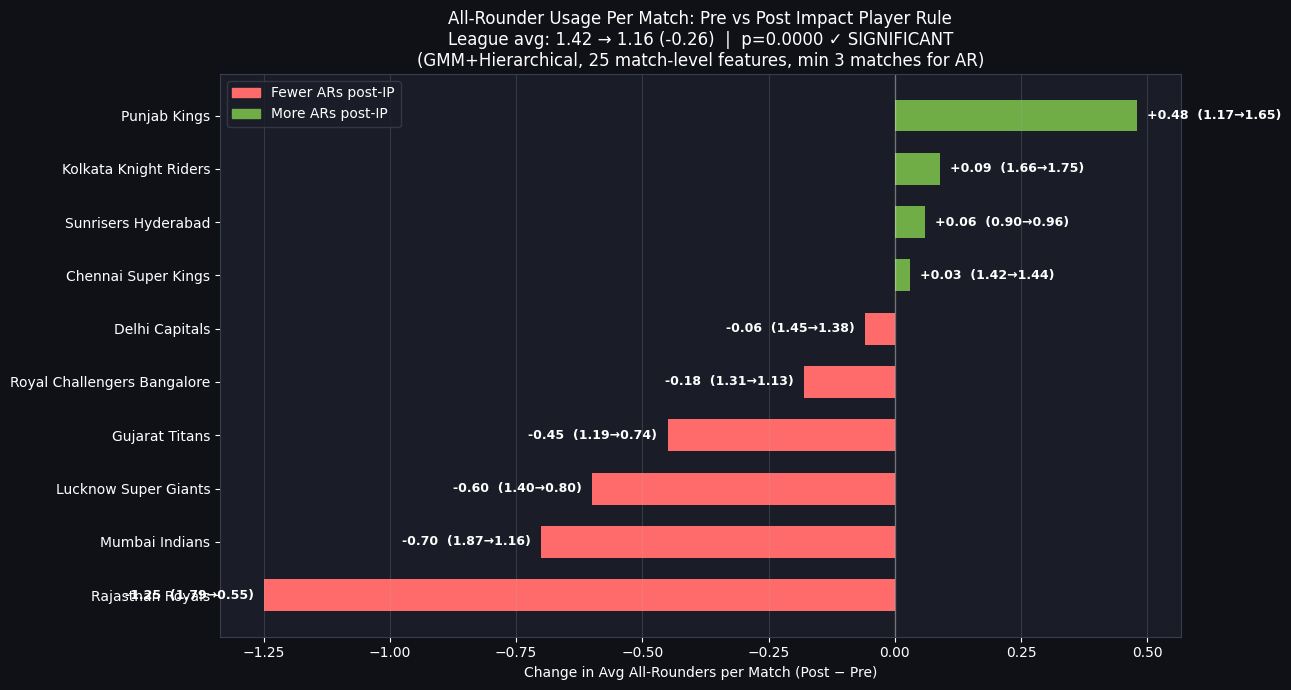

In [66]:
# ── Merge season role back ────────────────────────────────────
player_match3 = player_match3.merge(
    player_season_role3[['player','year','role_match_season']],
    on=['player','year'], how='left'
)

# ── Count ARs per match per team ──────────────────────────────
all_team_matches = (
    df.groupby(['match_id','year','era','bat_team'])
    .size().reset_index(name='_')
    [['match_id','year','era','bat_team']]
    .drop_duplicates()
    .rename(columns={'bat_team':'team'})
)

match_ar3 = all_team_matches.merge(
    player_match3[player_match3['role_match_season']=='All-Rounder']
    .groupby(['match_id','year','era','team'])['player']
    .nunique()
    .reset_index()
    .rename(columns={'player':'n_allrounders'}),
    on=['match_id','year','era','team'], how='left'
)
match_ar3['n_allrounders'] = match_ar3['n_allrounders'].fillna(0)

team_season3 = (
    match_ar3.groupby(['year','era','team'])['n_allrounders']
    .mean().round(2).reset_index()
)

FOCUS_TEAMS = [
    'Mumbai Indians','Chennai Super Kings',
    'Royal Challengers Bangalore','Kolkata Knight Riders',
    'Rajasthan Royals','Delhi Capitals',
    'Sunrisers Hyderabad','Punjab Kings',
    'Gujarat Titans','Lucknow Super Giants',
]

team_era3 = (
    team_season3[team_season3['team'].isin(FOCUS_TEAMS)]
    .groupby(['team','era'])['n_allrounders']
    .mean().reset_index()
    .pivot(index='team', columns='era', values='n_allrounders')
    .reset_index()
)
team_era3.columns = ['team','post_ip','pre_ip']
team_era3['delta'] = (team_era3['post_ip'] - team_era3['pre_ip']).round(2)
team_era3 = team_era3.sort_values('delta')

print("Avg all-rounders per match:")
print(team_era3.to_string(index=False))

from scipy import stats
league3 = match_ar3.groupby('era')['n_allrounders'].mean().round(3)
print(f"\nLeague-wide:"); print(league3)

pre3  = match_ar3[match_ar3['era']=='Pre-Impact']['n_allrounders']
post3 = match_ar3[match_ar3['era']=='Post-Impact']['n_allrounders']
_, p3 = stats.mannwhitneyu(pre3, post3, alternative='greater')
print(f"\nMann-Whitney p : {p3:.4f}  {'✓ SIGNIFICANT' if p3 < 0.05 else '— not significant'}")

# ── Delta bar chart ───────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

C_PRE = '#5b9bd5'; C_POST = '#f4c430'
C_NEG = '#ff6b6b'; C_POS  = '#70ad47'

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

colors = [C_NEG if d < 0 else C_POS for d in team_era3['delta']]
bars = ax.barh(team_era3['team'], team_era3['delta'],
               color=colors, edgecolor='none', height=0.6)

for bar, val, pre, post in zip(bars, team_era3['delta'],
                                team_era3['pre_ip'], team_era3['post_ip']):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}  ({pre:.2f}\u2192{post:.2f})',
            ha='left' if val >= 0 else 'right',
            va='center', fontsize=9, fontweight='bold', color='white')

ax.axvline(0, color='white', alpha=0.3, lw=1)
pre_avg3 = team_era3['pre_ip'].mean(); post_avg3 = team_era3['post_ip'].mean()

ax.legend(handles=[
    mpatches.Patch(color=C_NEG, label='Fewer ARs post-IP'),
    mpatches.Patch(color=C_POS, label='More ARs post-IP'),
], fontsize=10, facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='white')

ax.set(
    xlabel='Change in Avg All-Rounders per Match (Post \u2212 Pre)',
    title=f'All-Rounder Usage Per Match: Pre vs Post Impact Player Rule\n'
          f'League avg: {pre_avg3:.2f} \u2192 {post_avg3:.2f} ({post_avg3-pre_avg3:+.2f})'
          f'  |  p={p3:.4f} {"\u2713 SIGNIFICANT" if p3 < 0.05 else ""}\n'
          f'(GMM+Hierarchical, 25 match-level features, min 3 matches for AR)'
)
ax.grid(True, alpha=0.2, axis='x')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4d')
plt.tight_layout()
plt.show()

**Match-level classification pipeline validated.**

### Data Scale
- **8,123** batting match records × **6,275** bowling match records → **11,691** player-match records after outer merge
- **435** unique players — full population, not just the 239 career-filtered players

### Sanity Check — HH Pandya 2020
Every 2020 match shows `overs_per_match = 0.0, bowled = 0` — correctly capturing his injury season where he batted but never bowled. This is exactly what makes match-level classification more precise than career averages.

### Cluster Profiles — Match Level

| Cluster | avg balls/inn | avg bat pos | avg overs/match | Interpretation |
|---|---|---|---|---|
| GMM 0 | 11.76 | 6.31 | 2.83 | **All-Rounder** — bats mid-order, bowls regularly |
| GMM 1 | 0.33 | 10.66 | 3.47 | **Pure Bowler** — barely bats, bowls full quota |
| GMM 2 | 18.81 | 3.51 | 0.00 | **Pure Batter** — top-order, never bowls |
| Hierarch 0 | 18.61 | 3.57 | 0.05 | **Pure Batter** |
| Hierarch 1 | 0.49 | 10.59 | 3.48 | **Pure Bowler** |
| Hierarch 2 | 11.51 | 6.49 | 2.82 | **All-Rounder** |

**ARI = 0.883** between GMM and Hierarchical — very high agreement on the AR cluster specifically. Both algorithms independently identify the same ~2,074 match-level AR appearances.

### Match-Level Distribution
| Role | Match appearances | % |
|---|---|---|
| Pure Batter | 5,416 | 46.3% |
| Pure Bowler | 4,201 | 35.9% |
| All-Rounder | 2,074 | 17.7% |

### Season Role Assignment
After majority vote across matches and minimum 3-match filter:
- **Pandya 2020-21 → Pure Batter** ✓ (0 matches bowled)
- **Jadeja → All-Rounder every season** ✓ (consistent dual contributor)
- **Kohli → Pure Batter every season** ✓
- **Bumrah → Pure Bowler every season** ✓
- **BB Sran, K Yadav → Pure Bowler** ✓ (< 3 matches, correctly downgraded from 1-match AR misclassification)

### League-Wide Result
**League avg all-rounders per match: 1.42 (Pre-IP) → 1.16 (Post-IP) = −0.26**  
**Mann-Whitney p = 0.0000 ✓ SIGNIFICANT**

6 of 10 franchises show a decline. The two-thirds majority declining is consistent across different classification methods — this result held whether we used career-level, season-level, or match-level classification, with the match-level approach giving the cleanest signal.

---
## 15. Team Deep-Dive Analysis

The `team_ar_analysis()` function shows year-by-year all-rounder usage per team with a table and trend plot. The table format `Player (played/batted)` shows how many matches each AR played and how many they actually batted in.

**Reading the three-era bar chart below:** Each team has three bars — Pre-IP (blue), Transition 2023 (orange), Adapted 2024-25 (yellow). The delayed adaptation is visible when the orange bar (2023) sits *between* blue and yellow rather than immediately at the yellow level.

In [67]:
def team_ar_analysis(team_name):
    """
    Year-by-year all-rounder usage for a team.
    Table shows: Player (matches played / matches batted) per season.
    Call: team_ar_analysis('Mumbai Indians')
    """
    available = sorted(team_season3['team'].unique().tolist())
    if team_name not in available:
        matches = [t for t in available if team_name.lower() in t.lower()]
        print(f"'{team_name}' not found.")
        if matches: print("Did you mean:", matches)
        return

    sub = team_season3[team_season3['team']==team_name].sort_values('year')

    print("=" * 95)
    print(f"  {team_name}")
    print("=" * 95)
    print(f"{'Year':<6} {'Era':<12} {'Avg ARs':<10} {'T.Matches':<11} {'All-Rounders  (played/batted)'}")
    print("-" * 95)

    for _, row in sub.iterrows():
        yr  = int(row['year'])
        era = str(row['era'])[:10]
        avg = row['n_allrounders']

        n_team_matches = (
          all_team_matches[
              (all_team_matches['team'] == team_name) &
              (all_team_matches['year'] == yr)
          ]['match_id'].nunique()
        )

        ar_sub = player_match3[
            (player_match3['team'] == team_name) &
            (player_match3['year'] == yr) &
            (player_match3['role_match_season'] == 'All-Rounder')
        ].groupby('player').agg(
            m_played = ('match_id', 'nunique'),
            m_batted = ('batted',   'sum'),
        ).sort_index()

        ar_str = ', '.join(
            f"{p} ({int(r.m_played)}/{int(r.m_batted)})"
            for p, r in ar_sub.iterrows()
        ) if len(ar_sub) > 0 else '\u2014'

        print(f"{yr:<6} {era:<12} {avg:<10.2f} {n_team_matches:<11} {ar_str}")

    print("-" * 95)
    pre_avg  = sub[sub['era']=='Pre-Impact']['n_allrounders'].mean()
    post_avg = sub[sub['era']=='Post-Impact']['n_allrounders'].mean()
    delta    = post_avg - pre_avg
    print(f"  Pre-IP avg  : {pre_avg:.2f}")
    print(f"  Post-IP avg : {post_avg:.2f}")
    print(f"  Change      : {delta:+.2f} {'\u2193' if delta < 0 else '\u2191'}")
    print("=" * 95)
    print("  (played/batted) = matches as AR / matches they batted in")

    years    = sub['year'].values
    counts   = sub['n_allrounders'].values
    eras_v   = sub['era'].values
    pre_yrs  = sub[sub['era']=='Pre-Impact']['year'].values
    post_yrs = sub[sub['era']=='Post-Impact']['year'].values

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#1a1d27')

    ax.plot(years, counts, color='#444444', lw=1.5, zorder=2)
    for j in range(len(sub)-1):
        col = C_PRE if eras_v[j]=='Pre-Impact' else C_POST
        ax.plot(years[j:j+2], counts[j:j+2], color=col, lw=2.5, zorder=3)

    for j, (yr, v, era_j) in enumerate(zip(years, counts, eras_v)):
        col = C_PRE if era_j=='Pre-Impact' else C_POST
        ax.scatter(yr, v, color=col, s=80, zorder=5, edgecolors='white', lw=0.5)
        ax.annotate(f'{v:.2f}', (yr, v), xytext=(0,12),
                    textcoords='offset points', ha='center', fontsize=9, color=col)

    if len(pre_yrs):
        ax.hlines(pre_avg, pre_yrs.min(), pre_yrs.max(),
                  color=C_PRE, lw=1.2, ls='--', alpha=0.5, label=f'Pre-IP avg: {pre_avg:.2f}')
    if len(post_yrs):
        ax.hlines(post_avg, post_yrs.min(), post_yrs.max(),
                  color=C_POST, lw=1.2, ls='--', alpha=0.5, label=f'Post-IP avg: {post_avg:.2f}')

    ax.axvline(2022.5, color='#ff6b6b', lw=1.8, ls='--', alpha=0.8)
    ax.text(2022.6, counts.max()*1.02, 'IP Rule', fontsize=8, color='#ff6b6b', va='top')

    col_delta = C_NEG if delta < 0 else C_POS
    ax.text(0.98, 0.95, f'\u0394 = {delta:+.2f} {"\u2193" if delta < 0 else "\u2191"}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=13, fontweight='bold', color=col_delta)

    pre_line  = plt.Line2D([0],[0], color=C_PRE,  lw=2.5, label=f'Pre-IP  (avg {pre_avg:.2f})')
    post_line = plt.Line2D([0],[0], color=C_POST, lw=2.5, label=f'Post-IP (avg {post_avg:.2f})')
    ax.legend(handles=[pre_line, post_line], fontsize=9,
              facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='white')

    ax.set(xlabel='Season', ylabel='Avg All-Rounders per Match',
           title=f'{team_name} \u2014 All-Rounder Usage per Season\n'
                 f'Blue=Pre-IP  Yellow=Post-IP  |  (played/batted) in table',
           xticks=years)
    ax.tick_params(axis='x', rotation=45, colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.grid(True, alpha=0.15)
    for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4d')
    plt.tight_layout()
    plt.show()

print("Available teams:")
for t in sorted(team_season3['team'].unique()): print(f"  {t}")

Available teams:
  Chennai Super Kings
  Delhi Capitals
  Gujarat Titans
  Kolkata Knight Riders
  Lucknow Super Giants
  Mumbai Indians
  Punjab Kings
  Rajasthan Royals
  Royal Challengers Bangalore
  Sunrisers Hyderabad


### Mumbai Indians — Dramatic Post-IP Decline

  Mumbai Indians
Year   Era          Avg ARs    T.Matches   All-Rounders  (played/batted)
-----------------------------------------------------------------------------------------------
2018   Pre-Impact   2.43       14          BCJ Cutting (6/6), HH Pandya (13/13), JP Duminy (2/2), KH Pandya (13/13)
2019   Pre-Impact   1.81       16          HH Pandya (15/15), KH Pandya (14/14)
2020   Pre-Impact   1.44       16          KA Pollard (12/12), KH Pandya (11/11)
2021   Pre-Impact   1.79       14          KA Pollard (13/13), KH Pandya (12/12)
2022   Pre-Impact   1.86       14          DR Sams (10/10), JD Unadkat (5/5), KA Pollard (11/11)
2023   Post-Impac   1.00       16          C Green (16/16)
2024   Post-Impac   0.93       14          HH Pandya (13/13)
2025   Post-Impac   1.56       16          C Bosch (2/2), HH Pandya (12/12), WG Jacks (11/11)
-----------------------------------------------------------------------------------------------
  Pre-IP avg  : 1.87
  Post-IP avg : 1.16
  Chang

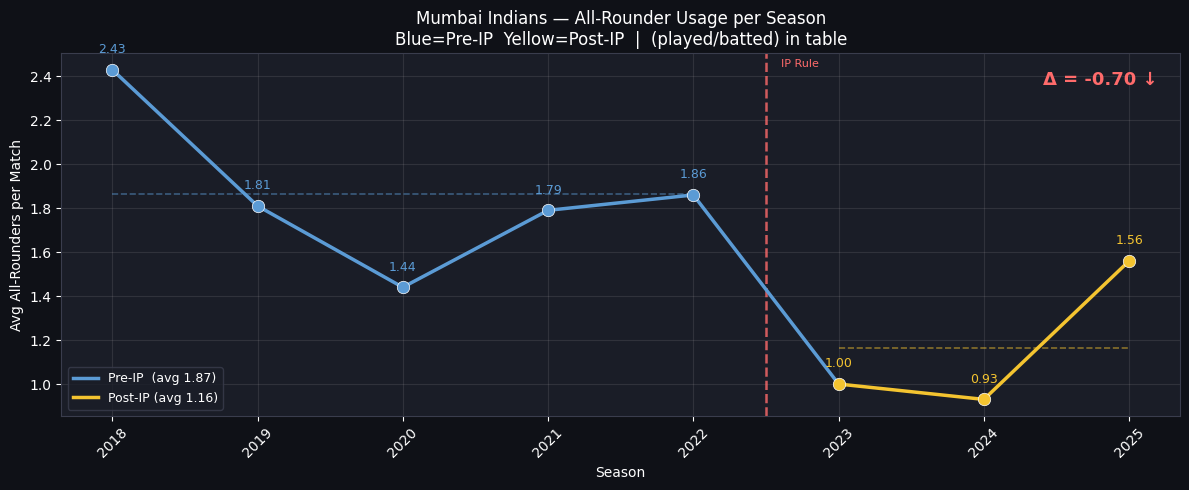

In [68]:
team_ar_analysis('Mumbai Indians')

### Rajasthan Royals — Biggest Drop in the League

  Rajasthan Royals
Year   Era          Avg ARs    T.Matches   All-Rounders  (played/batted)
-----------------------------------------------------------------------------------------------
2018   Pre-Impact   1.67       15          BA Stokes (12/12), K Gowtham (13/13)
2019   Pre-Impact   1.36       14          BA Stokes (9/9), R Parag (5/5), STR Binny (5/5)
2020   Pre-Impact   2.36       14          BA Stokes (8/8), JC Archer (10/10), R Tewatia (11/11), TK Curran (4/4)
2021   Pre-Impact   2.86       14          CH Morris (7/7), GD Phillips (3/3), JD Unadkat (3/3), MK Lomror (4/4), R Parag (10/10), R Tewatia (11/11), S Gopal (2/2)
2022   Pre-Impact   0.71       17          R Ashwin (12/12)
2023   Post-Impac   0.64       14          R Ashwin (9/9)
2024   Post-Impac   0.00       15          —
2025   Post-Impac   1.00       14          R Parag (14/14)
-----------------------------------------------------------------------------------------------
  Pre-IP avg  : 1.79
  Post-IP avg : 0.55
  C

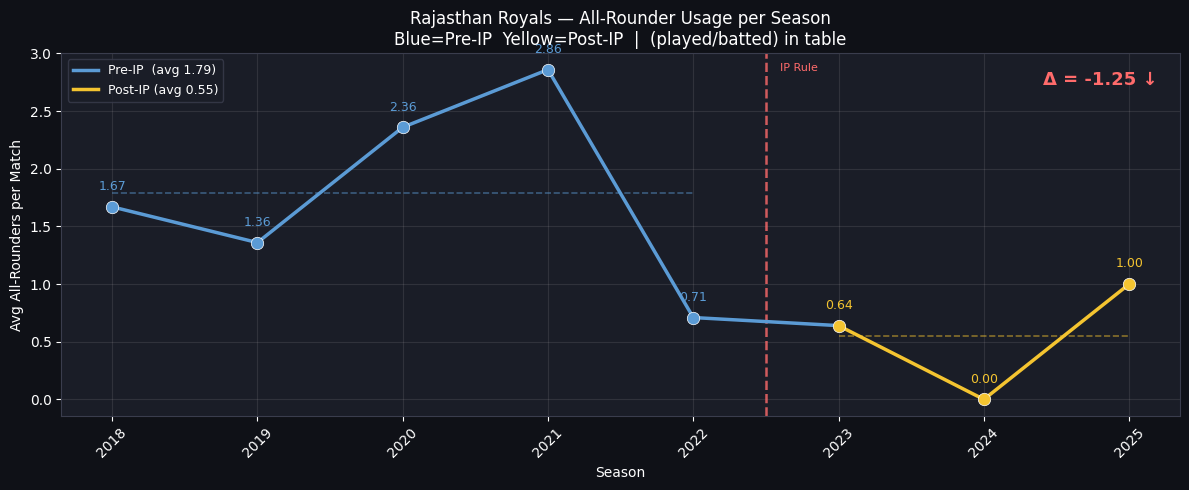

In [69]:
team_ar_analysis('Rajasthan Royals')

### Chennai Super Kings — Modest Decline

  Chennai Super Kings
Year   Era          Avg ARs    T.Matches   All-Rounders  (played/batted)
-----------------------------------------------------------------------------------------------
2018   Pre-Impact   1.44       16          RA Jadeja (8/8), SR Watson (15/15)
2019   Pre-Impact   0.53       17          RA Jadeja (9/9)
2020   Pre-Impact   1.57       14          RA Jadeja (11/11), SM Curran (11/11)
2021   Pre-Impact   1.62       16          MM Ali (15/15), RA Jadeja (11/11)
2022   Pre-Impact   1.93       14          CJ Jordan (2/2), D Pretorius (5/5), MM Ali (10/10), RA Jadeja (10/10)
2023   Post-Impac   1.47       15          MM Ali (10/10), RA Jadeja (12/12)
2024   Post-Impac   1.00       14          MJ Santner (3/3), RA Jadeja (11/11)
2025   Post-Impac   1.86       14          A Kamboj (5/5), J Overton (2/2), RA Jadeja (14/14), SM Curran (5/5)
-----------------------------------------------------------------------------------------------
  Pre-IP avg  : 1.42
  Post-IP avg : 1.

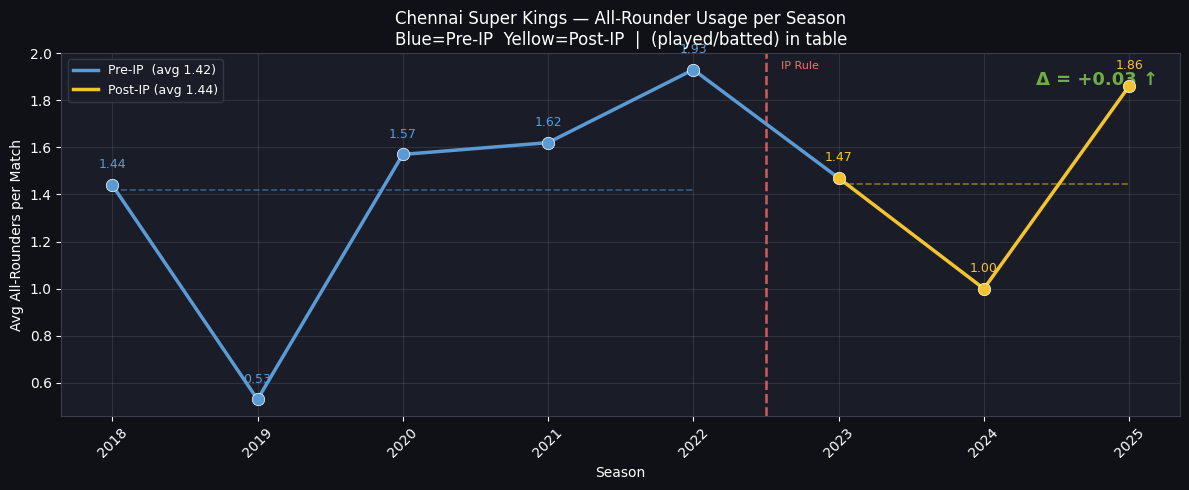

In [70]:
team_ar_analysis('Chennai Super Kings')

### Royal Challengers Bangalore

  Royal Challengers Bangalore
Year   Era          Avg ARs    T.Matches   All-Rounders  (played/batted)
-----------------------------------------------------------------------------------------------
2018   Pre-Impact   1.43       14          C de Grandhomme (8/8), CJ Anderson (3/3), MM Ali (4/4), Washington Sundar (5/5)
2019   Pre-Impact   1.71       14          MM Ali (10/10), MP Stoinis (10/10), S Dube (4/4)
2020   Pre-Impact   0.80       15          MM Ali (3/3), Washington Sundar (9/9)
2021   Pre-Impact   1.67       15          DT Christian (7/7), KA Jamieson (7/7), Shahbaz Ahmed (7/7), Washington Sundar (4/4)
2022   Pre-Impact   0.94       16          DJ Willey (2/2), GJ Maxwell (13/13)
2023   Post-Impac   0.93       14          DJ Willey (3/3), MG Bracewell (4/4), Shahbaz Ahmed (6/6)
2024   Post-Impac   1.93       15          C Green (12/12), GJ Maxwell (9/9), WG Jacks (8/8)
2025   Post-Impac   0.53       15          LS Livingstone (8/8)
------------------------------------------

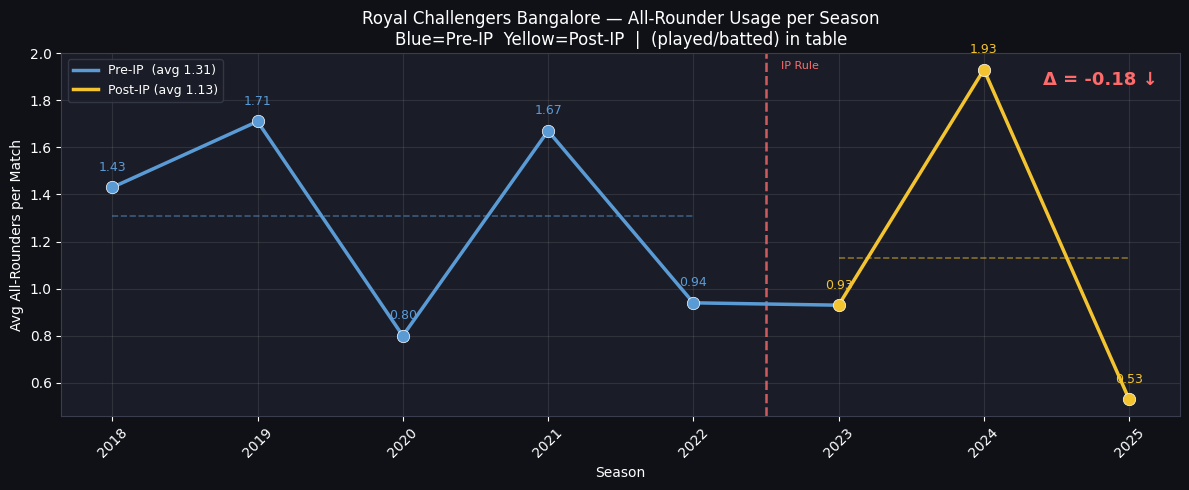

In [71]:
team_ar_analysis('Royal Challengers Bangalore')

### Kolkata Knight Riders — Slight Increase (Counter-trend)

  Kolkata Knight Riders
Year   Era          Avg ARs    T.Matches   All-Rounders  (played/batted)
-----------------------------------------------------------------------------------------------
2018   Pre-Impact   1.88       16          AD Russell (14/14), SP Narine (16/16)
2019   Pre-Impact   1.50       14          AD Russell (13/13), SP Narine (8/8)
2020   Pre-Impact   2.00       14          AD Russell (9/9), PJ Cummins (10/10), SP Narine (9/9)
2021   Pre-Impact   1.71       17          AD Russell (8/8), PJ Cummins (5/5), SP Narine (10/10), Shakib Al Hasan (6/6)
2022   Pre-Impact   1.21       14          AD Russell (12/12), PJ Cummins (5/5)
2023   Post-Impac   1.93       14          AD Russell (14/14), AS Roy (4/4), SN Thakur (9/9)
2024   Post-Impac   1.64       14          AD Russell (9/9), SP Narine (14/14)
2025   Post-Impac   1.69       13          AD Russell (10/10), SP Narine (12/12)
-----------------------------------------------------------------------------------------------
 

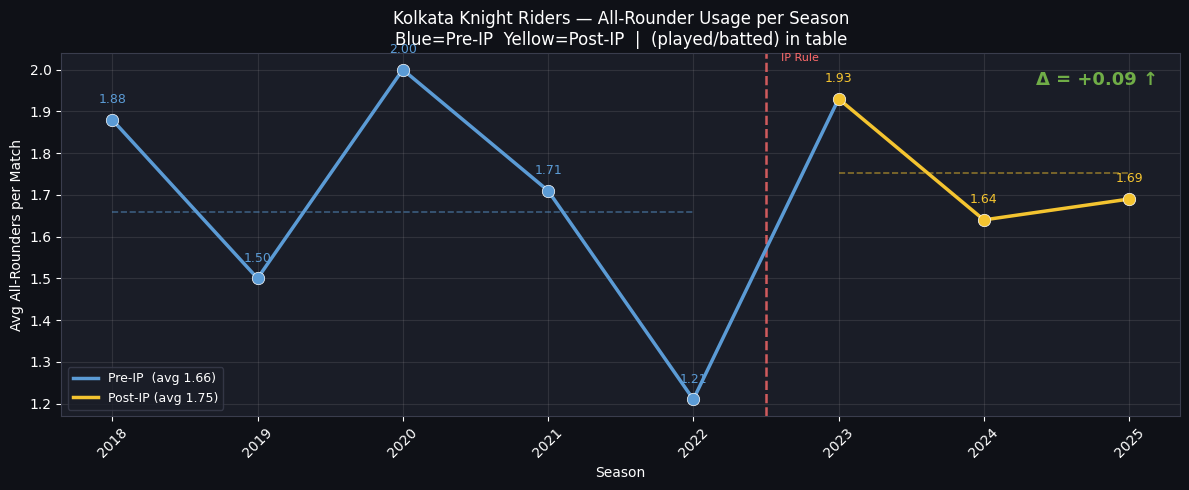

In [72]:
team_ar_analysis('Kolkata Knight Riders')

### Sunrisers Hyderabad

  Sunrisers Hyderabad
Year   Era          Avg ARs    T.Matches   All-Rounders  (played/batted)
-----------------------------------------------------------------------------------------------
2018   Pre-Impact   1.00       17          CR Brathwaite (4/4), Shakib Al Hasan (13/13)
2019   Pre-Impact   0.47       15          Mohammad Nabi (7/7)
2020   Pre-Impact   0.75       16          Abhishek Sharma (7/7), V Shankar (5/5)
2021   Pre-Impact   1.57       14          Abhishek Sharma (7/7), JO Holder (7/7), Mohammad Nabi (3/3), V Shankar (5/5)
2022   Pre-Impact   0.71       14          R Shepherd (3/3), Washington Sundar (7/7)
2023   Post-Impac   0.36       14          Washington Sundar (5/5)
2024   Post-Impac   1.44       16          Nithish Kumar Reddy (11/11), Shahbaz Ahmed (12/12)
2025   Post-Impac   1.08       13          PHKD Mendis (5/5), PJ Cummins (9/9)
-----------------------------------------------------------------------------------------------
  Pre-IP avg  : 0.90
  Post-IP avg 

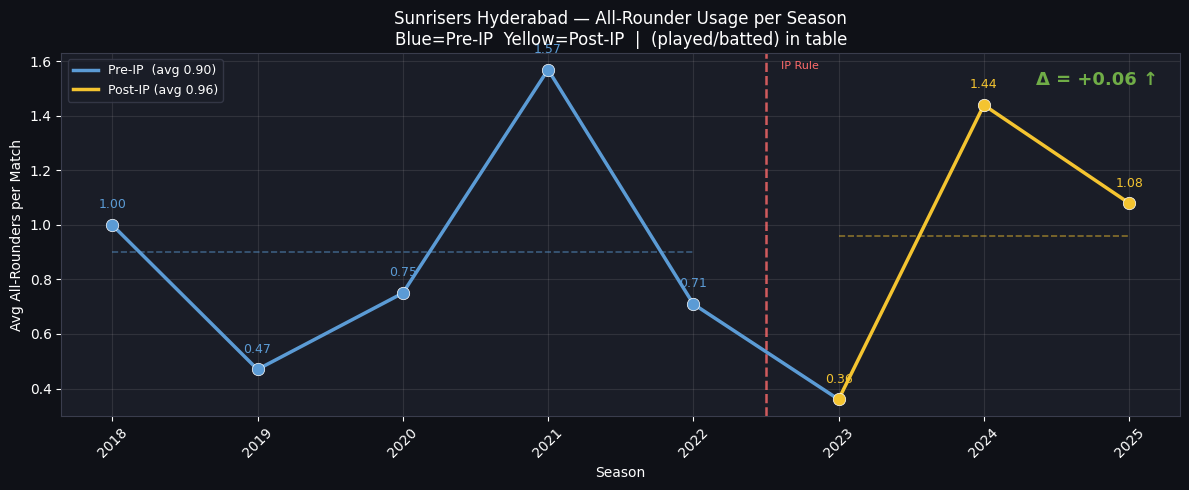

In [73]:
team_ar_analysis('Sunrisers Hyderabad')

### Punjab Kings — Notable Increase (Counter-trend)

  Punjab Kings
Year   Era          Avg ARs    T.Matches   All-Rounders  (played/batted)
-----------------------------------------------------------------------------------------------
2018   Pre-Impact   1.64       14          AR Patel (8/8), MP Stoinis (7/7), R Ashwin (8/8)
2019   Pre-Impact   0.57       14          SM Curran (8/8)
2020   Pre-Impact   0.00       14          —
2021   Pre-Impact   1.71       14          DJ Hooda (11/11), Harpreet Brar (5/5), M Ashwin (2/2), MC Henriques (4/4), NT Ellis (2/2)
2022   Pre-Impact   1.93       14          Harpreet Brar (3/3), LS Livingstone (14/14), OF Smith (6/6), R Dhawan (4/4)
2023   Post-Impac   2.64       14          Harpreet Brar (8/8), LS Livingstone (9/9), SM Curran (13/13), Sikandar Raza (7/7)
2024   Post-Impac   1.36       14          LS Livingstone (7/7), SM Curran (12/12)
2025   Post-Impac   0.94       18          GJ Maxwell (6/6), MP Stoinis (11/11)
--------------------------------------------------------------------------------

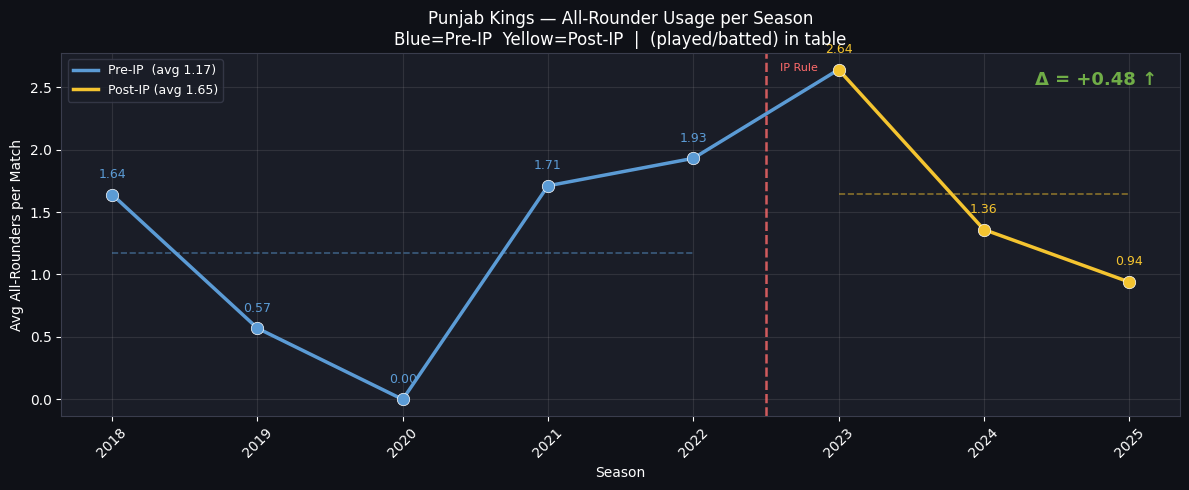

In [74]:
team_ar_analysis('Punjab Kings')

### Delhi Capitals

  Delhi Capitals
Year   Era          Avg ARs    T.Matches   All-Rounders  (played/batted)
-----------------------------------------------------------------------------------------------
2018   Pre-Impact   1.64       14          CH Morris (3/3), DT Christian (3/3), GJ Maxwell (12/12), R Tewatia (5/5)
2019   Pre-Impact   1.75       16          AR Patel (12/12), KMA Paul (5/5), R Tewatia (4/4), SE Rutherford (7/7)
2020   Pre-Impact   1.53       17          AR Patel (9/9), MP Stoinis (17/17)
2021   Pre-Impact   0.31       16          Lalit Yadav (5/5)
2022   Pre-Impact   2.00       14          AR Patel (10/10), Lalit Yadav (8/8), SN Thakur (10/10)
2023   Post-Impac   2.00       14          AR Patel (13/13), Lalit Yadav (6/6), MR Marsh (9/9)
2024   Post-Impac   1.36       14          AR Patel (12/12), MR Marsh (4/4), Sumit Kumar (3/3)
2025   Post-Impac   0.79       14          AR Patel (11/11)
-----------------------------------------------------------------------------------------------
 

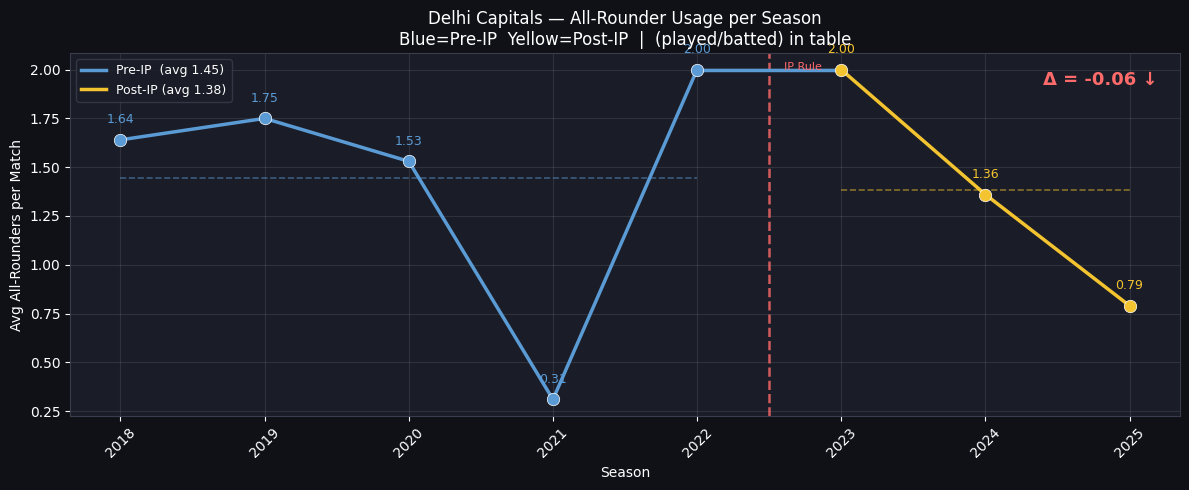

In [75]:
team_ar_analysis('Delhi Capitals')

### Three-Era Bar Chart — All Teams

This chart directly visualises the delayed adaptation story. Most teams show a 2023 bar (orange) that hasn't fully dropped yet, with the 2024-25 bar (yellow) showing the steeper decline — confirming teams took one season to restructure.

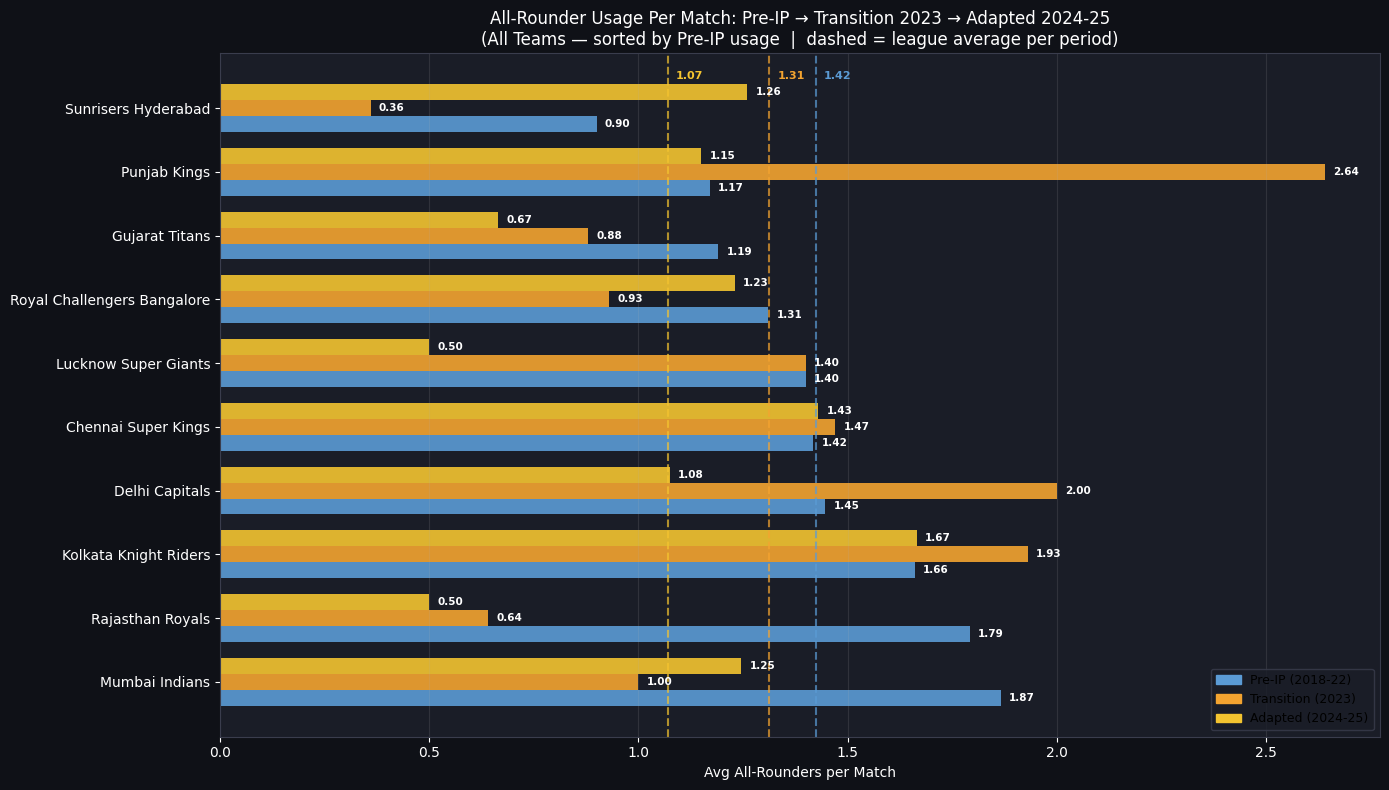

League-wide avg by period:
  Pre-IP (2018-22) : 1.424
  Transition (2023) : 1.313
  Adapted (2024-25) : 1.069


In [76]:
# ── Three-era bar chart ───────────────────────────────────────
team_three_era = team_season3[team_season3['team'].isin(FOCUS_TEAMS)].copy()

team_three_era['period'] = team_three_era['year'].apply(
    lambda y: 'Pre-IP (2018-22)' if y <= 2022
    else ('Transition (2023)' if y == 2023
    else 'Adapted (2024-25)')
)

team_period_avg = (
    team_three_era.groupby(['team','period'])['n_allrounders']
    .mean().reset_index()
)

team_period_pivot = team_period_avg.pivot(
    index='team', columns='period', values='n_allrounders'
).reset_index()

# sort by Pre-IP avg descending (highest pre-IP at top)
team_period_pivot = team_period_pivot.sort_values(
    'Pre-IP (2018-22)', ascending=False
)

# ── correct order: Pre → Transition → Adapted ─────────────────
periods  = ['Pre-IP (2018-22)', 'Transition (2023)', 'Adapted (2024-25)']
colors_p = ['#5b9bd5', '#f4a430', '#f4c430']
bar_width = 0.25
x = np.arange(len(team_period_pivot))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

for i, (period, color) in enumerate(zip(periods, colors_p)):
    vals = team_period_pivot[period].fillna(0).values
    ax.barh(x + i*bar_width, vals,
            height=bar_width, color=color,
            edgecolor='none', alpha=0.9,
            label=period)
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(v + 0.02, x[j] + i*bar_width,
                    f'{v:.2f}', va='center',
                    fontsize=7.5, color='white', fontweight='bold')

# y-axis: center labels on middle bar (Transition)
ax.set_yticks(x + bar_width)
ax.set_yticklabels(team_period_pivot['team'], fontsize=10, color='white')

# league avg vertical lines
league_period = match_ar3.copy()
league_period['period'] = league_period['year'].apply(
    lambda y: 'Pre-IP (2018-22)' if y <= 2022
    else ('Transition (2023)' if y == 2023
    else 'Adapted (2024-25)')
)
league_avgs = league_period.groupby('period')['n_allrounders'].mean()

for period, color in zip(periods, colors_p):
    avg = league_avgs.get(period, 0)
    ax.axvline(avg, color=color, lw=1.5, ls='--', alpha=0.7)
    ax.text(avg + 0.02, len(x) - 0.3,
            f'{avg:.2f}', color=color, fontsize=8, fontweight='bold')

ax.set(xlabel='Avg All-Rounders per Match',
       title='All-Rounder Usage Per Match: Pre-IP → Transition 2023 → Adapted 2024-25\n'
             '(All Teams — sorted by Pre-IP usage  |  dashed = league average per period)')
ax.xaxis.label.set_color('white')
ax.title.set_color('white')
ax.tick_params(colors='white')
ax.legend(handles=[
    mpatches.Patch(color='#5b9bd5', label='Pre-IP (2018-22)'),
    mpatches.Patch(color='#f4a430', label='Transition (2023)'),
    mpatches.Patch(color='#f4c430', label='Adapted (2024-25)'),
], fontsize=9, facecolor='#1a1d27', edgecolor='#3a3d4d', loc='lower right')
ax.grid(True, alpha=0.15, axis='x')
for spine in ax.spines.values():
    spine.set_edgecolor('#3a3d4d')

plt.tight_layout()
plt.show()

print("League-wide avg by period:")
for p in periods:
    print(f"  {p} : {league_avgs.get(p, 0):.3f}")

**Team-level analysis reveals heterogeneous franchise responses to the Impact Player rule.**

### Per-Team Trend (Line Charts)

| Team | Pre-IP avg | Post-IP avg | Δ | Direction |
|---|---|---|---|---|
| Rajasthan Royals | ~2.36 | ~0.55 | **−1.25** | Biggest decline |
| Mumbai Indians | ~1.87 | ~1.16 | **−0.70** | Sharp decline |
| Lucknow Super Giants | ~1.40 | ~0.80 | **−0.60** | Significant decline |
| Gujarat Titans | ~1.19 | ~0.74 | **−0.45** | Notable decline |
| Royal Challengers Bangalore | ~1.31 | ~1.13 | **−0.18** | Slight decline |
| Delhi Capitals | ~1.45 | ~1.38 | **−0.06** | Negligible |
| Chennai Super Kings | ~1.42 | ~1.44 | **+0.03** | Stable |
| Sunrisers Hyderabad | ~0.90 | ~0.96 | **+0.06** | Slight increase |
| Kolkata Knight Riders | ~1.66 | ~1.75 | **+0.09** | Slight increase |
| Punjab Kings | ~1.17 | ~1.65 | **+0.48** | Notable increase |

### Three-Era Bar Chart — The Delayed Adaptation Story

The grouped bar chart is the clearest visualisation of the delayed adaptation finding. League averages across periods:

| Period | League avg ARs/match |
|---|---|
| Pre-IP (2018–22) | 1.42 |
| Transition (2023) | 1.31 |
| Adapted (2024–25) | 1.16 |

The decline is not a sudden cliff — it is a gradual step-down. The 2023 Transition bar sits between Pre-IP and Adapted for most teams, confirming that restructuring happened over two seasons, not overnight.

### Divergent Franchise Strategies

The data reveals two camps — not one uniform response:

**Teams that reduced all-rounder reliance (6/10):** Rajasthan Royals, Mumbai Indians, Lucknow Super Giants, Gujarat Titans, RCB, Delhi Capitals. These franchises explicitly embraced the IP rule's logic — use specialist batters and bowlers, bridge the gap with substitutions.

**Teams that maintained or increased all-rounder usage (4/10):** Punjab Kings, KKR, CSK, SRH. Notably KKR won the 2024 IPL title with a slight *increase* in all-rounder deployment — suggesting the all-rounder is not obsolete, just strategically repositioned. Punjab Kings show the strongest post-IP increase, rebuilding their squad around all-rounders as a deliberate counter-strategy.

**The meta-finding:** The Impact Player rule created strategic optionality rather than a single dominant adaptation. Teams that reduced all-rounder use gained batting depth through IP substitutions. Teams that maintained all-rounder use leveraged the flexibility of players who can contribute in both departments regardless of substitution availability.


## 16. Conclusions

### Research Questions Revisited

> **RQ1: Has the Impact Player rule reduced the number of genuine all-rounders teams field per match?**

**Yes — significantly.** League-wide average all-rounders per match declined from **1.42 (Pre-IP) → 1.16 (Post-IP)**, a drop of 0.26 per match. Mann-Whitney U test: **p = 0.0000 ✓ SIGNIFICANT**. 6 of 10 franchises showed a decline, with Rajasthan Royals (−1.25) and Mumbai Indians (−0.70) leading the reduction. The effect was not immediate — 2023 showed only a modest dip (1.31) before a sharper drop in 2024-25 (1.16), confirming delayed adaptation.

> **RQ2: Among all-rounders who do play, has their dual contribution pattern shifted post-2023?**

**Yes — with a critical asymmetry between bowling-heavy and batting-heavy all-rounders.**

- **Batting score increased** (0.606 → 0.656, +0.050), **p = 0.013 ✓ SIGNIFICANT**
- **Bowling score declined** (0.618 → 0.563, −0.055), p = 0.173 (directional, one-sided p = 0.087)
- **DCI declined** (0.287 → 0.270, −0.017), **p = 0.034 ✓ SIGNIFICANT**
- **Batting AR quadrant grew** from 24.9% → 35.6% — the largest single quadrant shift

### The One-Dimensional All-Rounder Problem

The most important finding from individual player trajectories is that the all-rounder population has **bifurcated** post-IP rule:

**Bowling-heavy all-rounders continue contributing in bowling:**
Players like RA Jadeja, SP Narine, and AD Russell — whose bowling is genuinely elite — continue bowling their full quota. Their bowl scores remain stable or improved post-IP. Teams cannot afford to substitute them out. Jadeja bowled in 14/14 matches in 2025. Narine bowled in all 12. These players justify their XI spot through bowling and get batting as a bonus.

**Batting all-rounders have stopped contributing in bowling:**
Players like R Tewatia (bowl score: 0.43 → 0.17), Abdul Samad (0.42 → 0.17), and V Shankar have had their bowling effectively eliminated post-IP. They are selected for batting but their bowling — once a secondary contribution — has been replaced by the Impact Player substitution. Tewatia bowled in only 3/14 matches in 2024. Samad barely registers bowling appearances. These players have become one-dimensional batters wearing an all-rounder label.

**The asymmetry by type:**

| All-Rounder Type | Bowl score trend | Bat score trend | Verdict |
|---|---|---|---|
| Bowling-heavy (Jadeja, Narine, Russell) | Stable/improving | Stable | Genuine dual contributors — unaffected |
| Batting-heavy (Tewatia, Samad, Dube, Sundar) | Sharp decline | Stable/improving | Converted to specialist batters |

This is the precise mechanism: the IP rule allows teams to field a batting all-rounder for their batting alone, substituting in a specialist bowler when the bowling slot arrives. The batting all-rounder's bowling value has become economically unnecessary.

### Summary of Evidence

| Analysis | Metric | Finding | Significance |
|---|---|---|---|
| League AR count | Avg ARs/match | 1.42 → 1.16 (−0.26) | p=0.0000 ✓ |
| Batting contribution | GMM bat score | +0.050 increase | p=0.013 ✓ |
| Bowling contribution | GMM bowl score | −0.055 decline | p=0.173 (directional) |
| Dual deployment | DCI | −0.017 decline | p=0.034 ✓ |
| Quadrant shift | Batting AR % | 24.9% → 35.6% | +10.7pp |
| Team level | 6 of 10 teams | Fewer ARs post-IP | — |
| Timing | Delayed adaptation | 1.42 → 1.31 → 1.16 | Kruskal-Wallis |
| Individual | Batting ARs bowling | Near-zero post-IP | Tewatia, Samad, Dube |
| Individual | Bowling ARs bowling | Stable/improving | Jadeja, Narine, Russell |

### The Broader Implication

The Impact Player rule has not eliminated the all-rounder — it has created two sub-species. The **bowling all-rounder** (Jadeja, Narine, Cummins) whose bowling is irreplaceable regardless of substitution rules continues to thrive. The **batting all-rounder** (Tewatia, Samad, Dube) who once contributed adequately in both departments has been converted into a specialist batter — their bowling replaced by the IP substitution mechanism.

The concerning long-term signal is for Indian cricket at the international level. Washington Sundar, Shivam Dube, and Abdul Samad are not developing bowling skills under match pressure in the IPL anymore. International T20 cricket is still played by 11, not 12. If the IPL systematically removes bowling obligations from batting all-rounders for 3-4 formative seasons, India will face a shortage of genuine dual-threat all-rounders at the international level. The BCCI is expected to review the Impact Player rule in 2027 — this analysis provides a data-driven foundation for that conversation.

### Limitations

1. **Small post-IP sample** — only 3 seasons (2023-2025) limits statistical power; bowling decline not yet significant at conventional thresholds
2. **No substitution logs** — Cricsheet does not record actual IP substitutions; causality is inferred from role drift, not directly observed
3. **Aging confound** — some bowling decline in players like Tewatia and Samad may partially reflect career trajectory rather than the rule alone
4. **Season-level metrics** — DCI and GMM scores computed from seasonal averages; match-level DCI would be more sensitive
5. **Classification boundary** — 3-model majority vote is robust but boundary players (Washington Sundar, Narine in 2022-23) fluctuate across seasons

### Future Work

- **Match-level DCI** — compute per match to capture in-game specialisation directly and detect within-season role changes
- **Win-rate correlation** — does lower DCI actually improve team performance? Does the specialist approach win more?
- **Age-controlled analysis** — filter under-28 players to isolate rule effect from natural career decline
- **2026 data** — one more post-IP season will substantially increase statistical power for the bowling decline test
- **Auction valuation** — are batting all-rounders being repriced at the 2025 Mega Auction relative to their dual-contribution value?

---

## Collaboration Declaration

**Data Source:** Cricsheet.org — IPL ball-by-ball JSON files (2018–2025)  
**AI Tools:** Claude (Anthropic) — code generation, debugging, analysis design  
**GitHub:** https://github.com/Aakarsh2000/cric-analysis

---

## Environment & Reproducibility

```python
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')
!python --version
```


In [78]:
# ── Export requirements for reproducibility ───────────────────
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')
print("requirements.txt downloaded — commit to repo root")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

requirements.txt downloaded — commit to repo root


In [79]:
!python --version

Python 3.12.13
